In [1]:
# ===== 0. Imports & Config =====
import os
import re
import math
import json
import random
import hashlib
import unicodedata
from pathlib import Path
from dataclasses import dataclass, asdict
from collections import Counter, defaultdict
from typing import Dict, List, Tuple, Optional

import numpy as np
import pandas as pd
from tqdm.auto import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import precision_recall_fscore_support, accuracy_score, roc_auc_score

from transformers import AutoTokenizer, AutoModel, get_linear_schedule_with_warmup, get_cosine_schedule_with_warmup

# Giảm lỗi attention/SDPA trên một số runtime Kaggle + transformers mới.
try:
    torch.backends.cuda.enable_flash_sdp(False)
    torch.backends.cuda.enable_mem_efficient_sdp(False)
    torch.backends.cuda.enable_math_sdp(True)
except Exception:
    pass

try:
    from rouge_score import rouge_scorer
    HAS_ROUGE_SCORE = True
except Exception:
    HAS_ROUGE_SCORE = False


@dataclass
class Config:
    # Kaggle: nếu muốn trỏ thẳng file, set DATA_PATH = "/kaggle/input/.../vims_fusion_dataset(3).csv"
    DATA_PATH: str = ""
    CSV_FILENAME: str = "vims_fusion_dataset_relabel_single_topic_v2.csv"
    MODEL_NAME: str = "vinai/phobert-base-v2"
    SAVE_DIRNAME: str = "phobert_cluster_rank_mmr_outputs"

    # Tokenization / runtime
    MAX_LEN: int = 256
    TOKENIZER_USE_FAST: bool = False
    DEBUG_CUDA_BATCH: bool = True
    USE_EAGER_ATTENTION: bool = True

    # Reproducibility
    SEED: int = 42

    # Training - giảm để chống overfitting trên dataset nhỏ/vừa
    BATCH_SIZE: int = 8
    GRAD_ACCUM_STEPS: int = 2
    N_EPOCHS: int = 5
    ENCODER_LR: float = 2e-6
    HEAD_LR: float = 1e-5
    WEIGHT_DECAY: float = 0.05
    WARMUP_RATIO: float = 0.15
    SCHEDULER_TYPE: str = "cosine"  # "linear" or "cosine"
    MAX_GRAD_NORM: float = 0.5
    EARLY_STOPPING_PATIENCE: int = 2
    DROPOUT: float = 0.30

    # Freeze PhoBERT để giảm overfitting
    FREEZE_EMBEDDINGS: bool = True
    FREEZE_FIRST_N_LAYERS: int = 4

    # Label source
    # Bài này là extractive sentence importance labeling: chỉ dùng label 0/1 từ CSV.
    # Không dùng oracle/auto từ gold summary vì gold summary có thể là abstractive/paraphrase, dễ gây lệch nhãn.
    LABEL_SOURCE: str = "csv"
    ORACLE_LABEL_THRESHOLD: float = 0.20  # chỉ dùng để debug/EDA, KHÔNG dùng trong train/decode/test

    # Numeric features bổ sung cho classifier.
    # Không dùng title/tags làm ngữ cảnh cho classifier.
    USE_NUMERIC_FEATURES: bool = True
    NUMERIC_FEATURE_COLUMNS: Tuple[str, ...] = (
        "sent_doc_pos_norm",
        "sent_clus_pos_norm",
        "n_words_norm",
        "doc_size_norm",
    )
    NUMERIC_FEATURE_PROJ_DIM: int = 16

    # Loss
    USE_FOCAL_LOSS: bool = True
    FOCAL_GAMMA: float = 1.0
    LABEL_SMOOTHING: float = 0.0
    POS_WEIGHT_MODE: str = "sqrt"  # "ratio", "sqrt", "none"
    POS_WEIGHT_CLIP_MAX: float = 1.5

    # Ranking loss: BCE/Focal vẫn là loss chính; ranking loss ép câu label=1 có logit cao hơn label=0 trong cùng cluster.
    USE_RANKING_LOSS: bool = True
    RANKING_LOSS_WEIGHT: float = 0.05
    RANKING_MARGIN: float = 0.30
    GROUP_BATCH_BY_CLUSTER: bool = True

    # Split by cluster_id để tránh leakage
    VAL_SIZE: float = 0.15
    TEST_SIZE: float = 0.10

    # Summary decoding: nhập 1 cluster -> chấm điểm câu -> MMR chống trùng.
    # Giữ decoder ở mức trung gian: không ép lấy quá nhiều câu, không dùng gold summary.
    TASK_MODE: str = "cluster_mmr"
    USE_ADAPTIVE_BUDGET: bool = False
    SUMMARY_MAX_SENTENCES: int = 5
    SUMMARY_MAX_WORDS: int = 180
    MIN_REQUIRED_SENTENCES: int = 1
    ADAPTIVE_MIN_SENTENCES: int = 1
    ADAPTIVE_MAX_SENTENCES: int = 6
    ADAPTIVE_MAX_WORDS: int = 180

    # MMR / scoring weights
    MMR_ALPHA: float = 0.65
    REDUNDANCY_WEIGHT: float = 0.30
    DOC_COVERAGE_WEIGHT: float = 0.06
    POSITION_BONUS_WEIGHT: float = 0.04
    CENTRALITY_WEIGHT: float = 0.06

    # Filtering / fallback
    MIN_SENT_SCORE: float = 0.25
    MAX_REDUNDANCY_JACCARD: float = 0.55

    # Checkpoint metric
    # Metric chính phải bám label 0/1: câu được chọn có trùng câu label=1 không.
    # ROUGE với gold summary chỉ để tham khảo vì gold summary có thể không lấy nguyên văn câu nguồn.
    BEST_METRIC: str = "selection_f1"  # "selection_f1" or "combined"
    COMBINED_F1_WEIGHT: float = 0.40
    COMBINED_SELECTION_WEIGHT: float = 0.60
    COMBINED_ROUGE_WEIGHT: float = 0.00

    # Tự tune decoder trên validation bằng selection_f1, dùng cache score để không predict PhoBERT lặp nhiều lần.
    TUNE_DECODER_EACH_EPOCH: bool = True
    DECODER_TUNE_MAX_CLUSTERS: int = 80  # set 0/None nếu muốn dùng toàn bộ validation
    DECODER_MIN_SENT_SCORE_GRID: Tuple[float, ...] = (0.15, 0.25, 0.35, 0.45)
    DECODER_MAX_SENTENCES_GRID: Tuple[int, ...] = (3, 5, 7)
    DECODER_MIN_REQUIRED_GRID: Tuple[int, ...] = (1, 2)
    DECODER_MMR_ALPHA_GRID: Tuple[float, ...] = (0.55, 0.65, 0.75)
    DECODER_REDUNDANCY_WEIGHT_GRID: Tuple[float, ...] = (0.25, 0.35)
    DECODER_CENTRALITY_WEIGHT_GRID: Tuple[float, ...] = (0.00, 0.06)

cfg = Config()

def seed_everything(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(cfg.SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
print(json.dumps(asdict(cfg), ensure_ascii=False, indent=2))

Device: cuda
{
  "DATA_PATH": "",
  "CSV_FILENAME": "vims_fusion_dataset_relabel_single_topic_v2.csv",
  "MODEL_NAME": "vinai/phobert-base-v2",
  "SAVE_DIRNAME": "phobert_cluster_rank_mmr_outputs",
  "MAX_LEN": 256,
  "TOKENIZER_USE_FAST": false,
  "DEBUG_CUDA_BATCH": true,
  "USE_EAGER_ATTENTION": true,
  "SEED": 42,
  "BATCH_SIZE": 8,
  "GRAD_ACCUM_STEPS": 2,
  "N_EPOCHS": 5,
  "ENCODER_LR": 2e-06,
  "HEAD_LR": 1e-05,
  "WEIGHT_DECAY": 0.05,
  "WARMUP_RATIO": 0.15,
  "SCHEDULER_TYPE": "cosine",
  "MAX_GRAD_NORM": 0.5,
  "EARLY_STOPPING_PATIENCE": 2,
  "DROPOUT": 0.3,
  "FREEZE_EMBEDDINGS": true,
  "FREEZE_FIRST_N_LAYERS": 4,
  "LABEL_SOURCE": "csv",
  "ORACLE_LABEL_THRESHOLD": 0.2,
  "USE_NUMERIC_FEATURES": true,
  "NUMERIC_FEATURE_COLUMNS": [
    "sent_doc_pos_norm",
    "sent_clus_pos_norm",
    "n_words_norm",
    "doc_size_norm"
  ],
  "NUMERIC_FEATURE_PROJ_DIM": 16,
  "USE_FOCAL_LOSS": true,
  "FOCAL_GAMMA": 1.0,
  "LABEL_SMOOTHING": 0.0,
  "POS_WEIGHT_MODE": "sqrt",
  "POS_WEIG

In [2]:
# ===== 1. Utility functions =====

def find_csv_path(filename: str, data_path: str = "") -> Path:
    """Tìm CSV trên local/Kaggle.
    Ưu tiên cfg.DATA_PATH nếu được set, sau đó tìm theo filename trong /kaggle/input.
    """
    if data_path:
        p = Path(data_path)
        if p.exists():
            return p
        raise FileNotFoundError(f"DATA_PATH không tồn tại: {data_path}")

    candidates = [
        Path.cwd() / filename,
        Path("/mnt/data") / filename,
        Path("/kaggle/working") / filename,
    ]
    for p in candidates:
        if p.exists():
            return p

    kaggle_input = Path("/kaggle/input")
    if kaggle_input.exists():
        matches = list(kaggle_input.rglob(filename))
        if matches:
            return matches[0]
        # fallback: nếu filename khác một chút, lấy CSV đầu tiên tìm được
        csv_matches = list(kaggle_input.rglob("*.csv"))
        if len(csv_matches) == 1:
            print(f"Không tìm thấy đúng tên {filename}, dùng CSV duy nhất trong /kaggle/input: {csv_matches[0]}")
            return csv_matches[0]
        elif len(csv_matches) > 1:
            print("Các file CSV tìm thấy trong /kaggle/input:")
            for p in csv_matches[:20]:
                print(" -", p)

    matches = list(Path.cwd().rglob(filename))
    if matches:
        return matches[0]

    raise FileNotFoundError(f"Cannot find {filename}. Hãy Add Data trên Kaggle hoặc set cfg.DATA_PATH.")



def normalize_for_model(text: str) -> str:
    """Normalize sau khi đã parse metadata. Không dùng hàm này trên raw text_fusion trước parse."""
    if pd.isna(text):
        return ""
    text = unicodedata.normalize("NFKC", str(text))
    text = text.replace("\xa0", " ")
    text = re.sub(r"\s+", " ", text).strip()
    return text


def simple_tokens(text: str) -> List[str]:
    text = normalize_for_model(text).lower()
    return re.findall(r"[\wÀ-ỹ]+", text, flags=re.UNICODE)


def jaccard_text(a: str, b: str) -> float:
    ta, tb = set(simple_tokens(a)), set(simple_tokens(b))
    if not ta or not tb:
        return 0.0
    return len(ta & tb) / max(1, len(ta | tb))


def stable_hash(text: str, n: int = 12) -> str:
    return hashlib.md5(normalize_for_model(text).lower().encode("utf-8")).hexdigest()[:n]


def count_words(text: str) -> int:
    return len(simple_tokens(text))

In [3]:
# ===== 2. Parse text_fusion without destroying metadata =====

META_PATTERNS = {
    "clus_id_marker": r"\[CLUS_ID_([^\]]+)\]",
    "doc_id": r"\[DOC_ID_([^\]]+)\]",
    "sent_clus_pos": r"\[SENT_CLUS_POS_([^\]]+)\]",
    "sent_doc_pos": r"\[SENT_DOC_POS_([^\]]+)\]",
}
META_REMOVE_RE = re.compile(
    r"\s*\[(?:CLUS_ID|DOC_ID|SENT_CLUS_POS|SENT_DOC_POS)_[^\]]+\]\s*"
)


def _extract_marker(raw: str, pattern: str):
    m = re.search(pattern, raw)
    return m.group(1).strip() if m else None


def _safe_int(x, default=-1):
    try:
        return int(str(x).strip())
    except Exception:
        return default


def parse_text_fusion(text_fusion: str) -> Dict:
    """
    Parse một dòng text_fusion có dạng:
    [CLUS_ID_x] [DOC_ID_y] [SENT_CLUS_POS_i] [SENT_DOC_POS_j] sentence
    |TITLE| title
    |TAGS| tags
    |SUMMARY| summary

    Lưu ý: chỉ normalize sau khi đã tách metadata.
    """
    raw = "" if pd.isna(text_fusion) else str(text_fusion)

    markers = {name: _extract_marker(raw, pat) for name, pat in META_PATTERNS.items()}

    # Split in a tolerant way. If a segment is missing, keep empty string.
    before_summary, summary = (raw.split("|SUMMARY|", 1) + [""])[:2] if "|SUMMARY|" in raw else (raw, "")
    before_tags, tags = (before_summary.split("|TAGS|", 1) + [""])[:2] if "|TAGS|" in before_summary else (before_summary, "")
    before_title, title = (before_tags.split("|TITLE|", 1) + [""])[:2] if "|TITLE|" in before_tags else (before_tags, "")

    sentence_text = META_REMOVE_RE.sub(" ", before_title)

    return {
        "clus_id_marker": markers["clus_id_marker"],
        "doc_id": markers["doc_id"],
        "sent_clus_pos": _safe_int(markers["sent_clus_pos"]),
        "sent_doc_pos": _safe_int(markers["sent_doc_pos"]),
        "sentence": normalize_for_model(sentence_text),
        "title": normalize_for_model(title),
        "tags": normalize_for_model(tags),
        "summary": normalize_for_model(summary),
    }


# Quick parse demo
_demo = "[CLUS_ID_1] [DOC_ID_2] [SENT_CLUS_POS_3] [SENT_DOC_POS_0] Đây là câu nguồn. |TITLE| Tiêu đề A |TAGS| tag1, tag2 |SUMMARY| Tóm tắt vàng."
parse_text_fusion(_demo)

{'clus_id_marker': '1',
 'doc_id': '2',
 'sent_clus_pos': 3,
 'sent_doc_pos': 0,
 'sentence': 'Đây là câu nguồn.',
 'title': 'Tiêu đề A',
 'tags': 'tag1, tag2',
 'summary': 'Tóm tắt vàng.'}

In [4]:
# ===== 3. ROUGE helpers =====

if HAS_ROUGE_SCORE:
    _rouge = rouge_scorer.RougeScorer(["rouge1", "rouge2", "rougeL"], use_stemmer=False)


def _ngrams(tokens: List[str], n: int):
    return list(zip(*[tokens[i:] for i in range(n)])) if len(tokens) >= n else []


def _f1_overlap(pred_tokens: List[str], ref_tokens: List[str], n: int = 1) -> float:
    pred_ngrams = Counter(_ngrams(pred_tokens, n))
    ref_ngrams = Counter(_ngrams(ref_tokens, n))
    if not pred_ngrams or not ref_ngrams:
        return 0.0
    overlap = sum((pred_ngrams & ref_ngrams).values())
    p = overlap / max(1, sum(pred_ngrams.values()))
    r = overlap / max(1, sum(ref_ngrams.values()))
    return 2 * p * r / max(1e-12, p + r)


def _lcs_len(a: List[str], b: List[str]) -> int:
    if not a or not b:
        return 0
    dp = [0] * (len(b) + 1)
    for x in a:
        prev = 0
        for j, y in enumerate(b, start=1):
            tmp = dp[j]
            dp[j] = prev + 1 if x == y else max(dp[j], dp[j-1])
            prev = tmp
    return dp[-1]


def rouge_scores(pred: str, ref: str) -> Dict[str, float]:
    pred = normalize_for_model(pred)
    ref = normalize_for_model(ref)
    if not pred or not ref:
        return {"rouge1": 0.0, "rouge2": 0.0, "rougeL": 0.0}

    if HAS_ROUGE_SCORE:
        s = _rouge.score(ref, pred)
        return {"rouge1": s["rouge1"].fmeasure, "rouge2": s["rouge2"].fmeasure, "rougeL": s["rougeL"].fmeasure}

    pt, rt = simple_tokens(pred), simple_tokens(ref)
    r1 = _f1_overlap(pt, rt, 1)
    r2 = _f1_overlap(pt, rt, 2)
    lcs = _lcs_len(pt, rt)
    p = lcs / max(1, len(pt))
    r = lcs / max(1, len(rt))
    rl = 2 * p * r / max(1e-12, p + r)
    return {"rouge1": r1, "rouge2": r2, "rougeL": rl}


def sentence_oracle_score(sentence: str, summary: str) -> float:
    return rouge_scores(sentence, summary)["rougeL"]

In [5]:
# ===== 4. Build sentence-level dataframe =====

def get_numeric_feature_columns(cfg: Config = cfg) -> List[str]:
    """Danh sách feature phụ đưa vào classification head.
    Có thể tắt nhanh bằng cfg.USE_NUMERIC_FEATURES = False.
    """
    if not getattr(cfg, "USE_NUMERIC_FEATURES", False):
        return []
    return list(getattr(cfg, "NUMERIC_FEATURE_COLUMNS", []))


def add_numeric_features(sent_df: pd.DataFrame, cfg: Config = cfg) -> pd.DataFrame:
    """Tạo numeric features không dùng gold summary để tránh leakage.

    Các feature này giúp classifier có thêm tín hiệu thực dụng mà không cần metadata:
    - vị trí câu trong document / cluster
    - độ dài câu
    - kích thước document trong cluster
    """
    df = sent_df.copy()

    # Bảo đảm sort ổn định trước khi tính cumcount.
    df = df.sort_values(
        ["cluster_id", "sent_clus_pos", "doc_id", "sent_doc_pos", "raw_index"],
        kind="stable"
    ).reset_index(drop=True)

    cluster_size = df.groupby("cluster_id")["sentence"].transform("size").astype(float)
    doc_keys = ["cluster_id", "doc_id"]
    doc_size = df.groupby(doc_keys, dropna=False)["sentence"].transform("size").astype(float)

    # Vị trí an toàn: nếu metadata thiếu (-1), dùng thứ tự thực tế sau sort.
    doc_order = df.groupby(doc_keys, dropna=False).cumcount().astype(float)
    cluster_order = df.groupby("cluster_id", dropna=False).cumcount().astype(float)

    sent_doc_pos = pd.to_numeric(df["sent_doc_pos"], errors="coerce").fillna(-1).astype(float)
    sent_clus_pos = pd.to_numeric(df["sent_clus_pos"], errors="coerce").fillna(-1).astype(float)

    safe_doc_pos = np.where(sent_doc_pos >= 0, sent_doc_pos, doc_order)
    safe_clus_pos = np.where(sent_clus_pos >= 0, sent_clus_pos, cluster_order)

    df["sent_doc_pos_norm"] = safe_doc_pos / np.maximum(doc_size.values - 1.0, 1.0)
    df["sent_clus_pos_norm"] = safe_clus_pos / np.maximum(cluster_size.values - 1.0, 1.0)

    n_words = pd.to_numeric(df["n_words"], errors="coerce").fillna(0).astype(float)
    df["n_words_norm"] = np.clip(np.log1p(n_words) / np.log1p(80.0), 0.0, 1.0)
    df["doc_size_norm"] = np.clip(doc_size.values / np.maximum(cluster_size.values, 1.0), 0.0, 1.0)

    feature_cols = get_numeric_feature_columns(cfg)
    for col in feature_cols:
        if col not in df.columns:
            df[col] = 0.0
        df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0.0).astype("float32")
        df[col] = df[col].clip(lower=0.0, upper=1.0)

    return df


def build_sentence_level_df(df_raw: pd.DataFrame) -> pd.DataFrame:
    required_cols = {"text_fusion", "label"}
    missing = required_cols - set(df_raw.columns)
    if missing:
        raise ValueError(f"Missing required columns: {missing}")

    rows = []
    for raw_idx, row in tqdm(df_raw.iterrows(), total=len(df_raw), desc="Parsing text_fusion"):
        parsed = parse_text_fusion(row["text_fusion"])
        cluster_id = row["cluster_id"] if "cluster_id" in df_raw.columns else parsed["clus_id_marker"]
        if pd.isna(cluster_id):
            cluster_id = parsed["clus_id_marker"]

        sentence = parsed["sentence"]
        if not sentence or count_words(sentence) < 2:
            continue

        # oracle_score chỉ để debug/EDA. Không dùng nó để tạo label, train, tune hay decode.
        oracle_score = sentence_oracle_score(sentence, parsed["summary"]) if parsed["summary"] else 0.0

        if cfg.LABEL_SOURCE != "csv":
            raise ValueError(
                "Bài này phải dùng cfg.LABEL_SOURCE='csv'. "
                "Không dùng 'oracle'/'auto' vì gold summary không nhất thiết lấy nguyên văn câu nguồn, "
                "dễ tạo label giả sai và gây data leakage."
            )

        raw_label = row.get("label", np.nan)
        if pd.isna(raw_label):
            raise ValueError("cfg.LABEL_SOURCE='csv' nhưng có dòng thiếu label trong CSV.")
        label = int(raw_label)

        rows.append({
            "raw_index": raw_idx,
            "cluster_id": cluster_id,
            "clus_id_marker": parsed["clus_id_marker"],
            "doc_id": parsed["doc_id"],
            "sent_clus_pos": parsed["sent_clus_pos"],
            "sent_doc_pos": parsed["sent_doc_pos"],
            "sentence": sentence,
            "title": parsed["title"],
            "tags": parsed["tags"],
            "summary": parsed["summary"],
            "label": label,
            "raw_label": raw_label if not pd.isna(raw_label) else np.nan,
            "oracle_score": oracle_score,
            "n_words": count_words(sentence),
        })

    sent_df = pd.DataFrame(rows)
    if sent_df.empty:
        raise ValueError("No valid sentence rows created. Check text_fusion format.")

    sent_df = add_numeric_features(sent_df, cfg)
    sent_df = sent_df.sort_values(["cluster_id", "sent_clus_pos", "doc_id", "sent_doc_pos", "raw_index"], kind="stable").reset_index(drop=True)
    sent_df["sent_global_index"] = np.arange(len(sent_df))
    return sent_df


def validate_sentence_dataframe(sent_df: pd.DataFrame, cfg: Config = cfg):
    """Kiểm tra nhanh để tránh CUDA device-side assert do label/input bẩn."""
    if sent_df.empty:
        raise ValueError("sent_df rỗng.")
    sent_df["label"] = pd.to_numeric(sent_df["label"], errors="coerce")
    bad = sent_df[~sent_df["label"].isin([0, 1])]
    if len(bad) > 0:
        print(bad[["cluster_id", "sentence", "label", "oracle_score"]].head(10))
        raise ValueError("Label phải chỉ gồm 0/1. Hãy kiểm tra LABEL_SOURCE hoặc ORACLE_LABEL_THRESHOLD.")
    sent_df["label"] = sent_df["label"].astype(int)
    print("Label source:", cfg.LABEL_SOURCE)
    print("Label counts:")
    print(sent_df["label"].value_counts(dropna=False).sort_index())
    print("Positive rate:", round(float(sent_df["label"].mean()), 4))
    return sent_df

# Load raw data and build dataframe
csv_path = find_csv_path(cfg.CSV_FILENAME, cfg.DATA_PATH)
print("CSV path:", csv_path)
raw_df = pd.read_csv(csv_path)
print("Raw shape:", raw_df.shape)
print(raw_df.head(2))

sent_df = build_sentence_level_df(raw_df)
print("Sentence-level shape:", sent_df.shape)
feature_cols = get_numeric_feature_columns(cfg)
if feature_cols:
    print("Numeric feature columns:", feature_cols)
    print(sent_df[feature_cols].describe().T[["mean", "std", "min", "max"]])
print(sent_df[["cluster_id", "doc_id", "sent_clus_pos", "sent_doc_pos", "label", "title", "tags", "sentence"]].head())
print("Label source:", cfg.LABEL_SOURCE)
print("Label distribution:", sent_df["label"].value_counts(normalize=True).to_dict())
if "raw_label" in sent_df.columns and sent_df["raw_label"].notna().any():
    print("Raw CSV label distribution:", sent_df["raw_label"].value_counts(normalize=True).to_dict())
print("Oracle-score positive rate at threshold", cfg.ORACLE_LABEL_THRESHOLD, ":", float((sent_df["oracle_score"] >= cfg.ORACLE_LABEL_THRESHOLD).mean()))
print("NOTE: oracle_score chỉ để debug độ lệch với gold summary; không tham gia train/decode/eval chính.")
print("Documents per cluster:")
print(sent_df.groupby("cluster_id")["doc_id"].nunique().describe())

CSV path: /kaggle/input/datasets/cngnguy3413/df-final/vims_fusion_dataset_relabel_single_topic_v2.csv
Raw shape: (25730, 3)
   cluster_id                                        text_fusion  label
0           1  [CLUS_ID_1] [DOC_ID_1] [SENT_CLUS_POS_0] [SENT...      1
1           1  [CLUS_ID_1] [DOC_ID_1] [SENT_CLUS_POS_1] [SENT...      0


Parsing text_fusion:   0%|          | 0/25730 [00:00<?, ?it/s]

Sentence-level shape: (25676, 19)
Numeric feature columns: ['sent_doc_pos_norm', 'sent_clus_pos_norm', 'n_words_norm', 'doc_size_norm']
                        mean       std       min       max
sent_doc_pos_norm   0.500924  0.312872  0.000000  1.000000
sent_clus_pos_norm  0.501059  0.292667  0.000000  1.000000
n_words_norm        0.697528  0.116066  0.250000  1.000000
doc_size_norm       0.178538  0.079624  0.008197  0.566667
   cluster_id doc_id  sent_clus_pos  sent_doc_pos  label  \
0           1      1              0             0      1   
1           1      1              1             1      0   
2           1      1              2             2      0   
3           1      1              3             3      0   
4           1      1              4             4      1   

                                              title  \
0  các nước chia buồn vụ tai_nạn máy_bay của ai cập   
1  các nước chia buồn vụ tai_nạn máy_bay của ai cập   
2  các nước chia buồn vụ tai_nạn máy_bay củ

In [6]:
# ===== 5. Split by cluster_id to avoid leakage =====

def split_by_cluster(df: pd.DataFrame, cfg: Config):
    groups = df["cluster_id"].astype(str).values

    # First split: train vs temp(val+test)
    gss1 = GroupShuffleSplit(n_splits=1, test_size=cfg.VAL_SIZE + cfg.TEST_SIZE, random_state=cfg.SEED)
    train_idx, temp_idx = next(gss1.split(df, df["label"], groups=groups))
    train_df = df.iloc[train_idx].reset_index(drop=True)
    temp_df = df.iloc[temp_idx].reset_index(drop=True)

    if cfg.TEST_SIZE <= 0 or temp_df["cluster_id"].nunique() < 2:
        return train_df, temp_df, pd.DataFrame(columns=df.columns)

    relative_test_size = cfg.TEST_SIZE / (cfg.VAL_SIZE + cfg.TEST_SIZE)
    gss2 = GroupShuffleSplit(n_splits=1, test_size=relative_test_size, random_state=cfg.SEED + 1)
    temp_groups = temp_df["cluster_id"].astype(str).values
    val_idx, test_idx = next(gss2.split(temp_df, temp_df["label"], groups=temp_groups))
    val_df = temp_df.iloc[val_idx].reset_index(drop=True)
    test_df = temp_df.iloc[test_idx].reset_index(drop=True)
    return train_df, val_df, test_df


train_df, val_df, test_df = split_by_cluster(sent_df, cfg)
print("Train/Val/Test:", train_df.shape, val_df.shape, test_df.shape)
print("Cluster counts:", train_df.cluster_id.nunique(), val_df.cluster_id.nunique(), test_df.cluster_id.nunique())
print("Overlap train-val:", set(train_df.cluster_id) & set(val_df.cluster_id))
print("Overlap train-test:", set(train_df.cluster_id) & set(test_df.cluster_id))
print("Train label distribution:", train_df.label.value_counts(normalize=True).to_dict())
print("Val label distribution:", val_df.label.value_counts(normalize=True).to_dict())

Train/Val/Test: (18680, 19) (4354, 19) (2642, 19)
Cluster counts: 225 45 30
Overlap train-val: set()
Overlap train-test: set()
Train label distribution: {0: 0.9117237687366168, 1: 0.0882762312633833}
Val label distribution: {0: 0.9251263206247129, 1: 0.07487367937528709}


=== KEY DATA STATS ===
Rows: 25676
Clusters: 300
Documents: 10
Documents per cluster:
count    300.000000
mean       6.483333
std        1.638701
min        4.000000
25%        5.000000
50%        6.000000
75%        7.000000
max       10.000000
Name: doc_id, dtype: float64

Label count by split:
label      0     1
split             
test    2416   226
train  17031  1649
val     4028   326

Positive rate by split:
split
test     0.085541
train    0.088276
val      0.074874
Name: label, dtype: float64


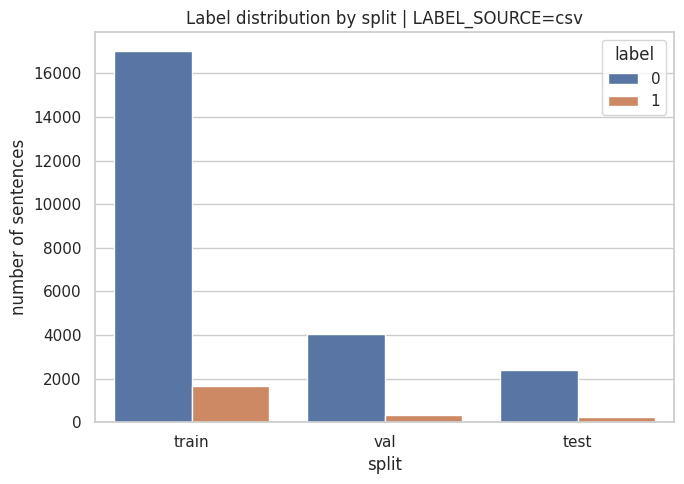

Saved: /kaggle/working/phobert_cluster_rank_mmr_outputs/01_key_label_distribution_by_split.png


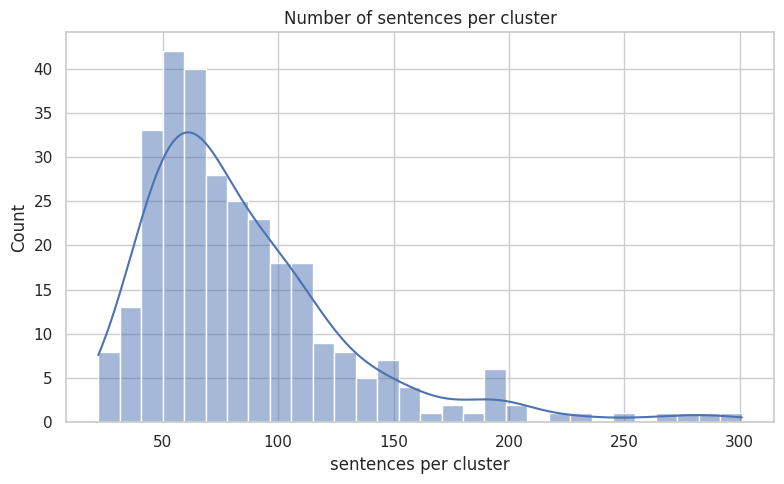

Saved: /kaggle/working/phobert_cluster_rank_mmr_outputs/02_key_sentences_per_cluster.png


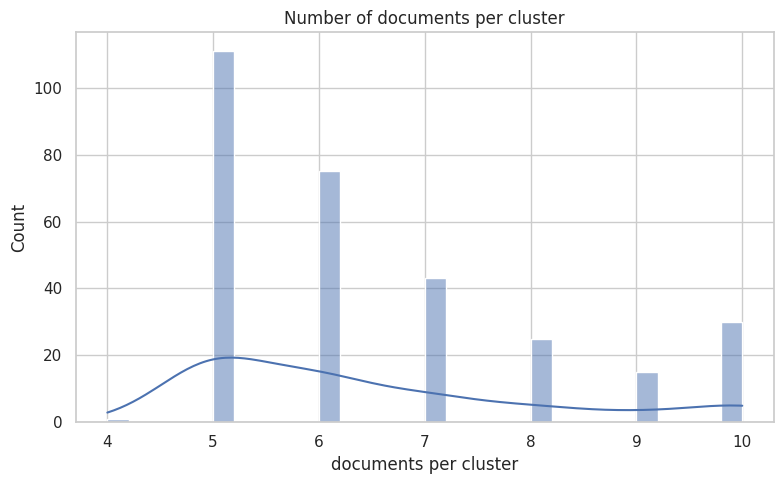

Saved: /kaggle/working/phobert_cluster_rank_mmr_outputs/03_key_documents_per_cluster.png


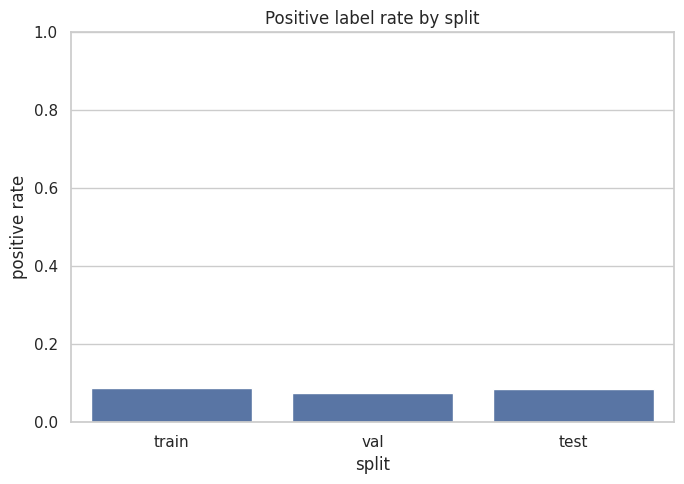

Saved: /kaggle/working/phobert_cluster_rank_mmr_outputs/04_key_positive_rate_by_split.png


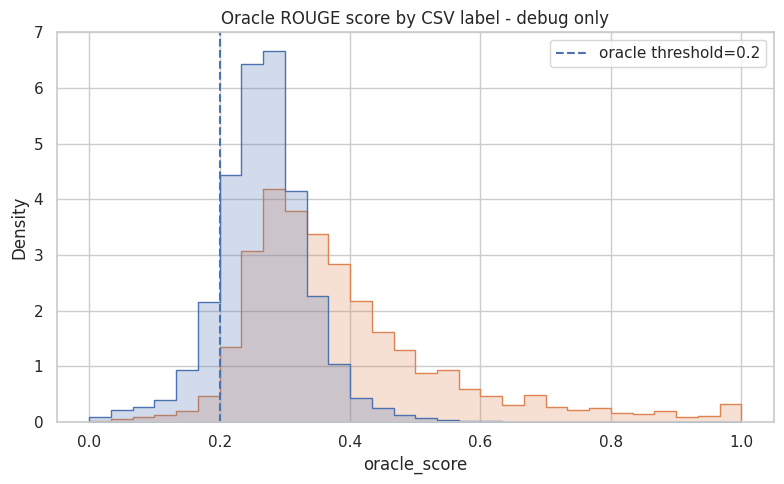

Saved: /kaggle/working/phobert_cluster_rank_mmr_outputs/05_key_oracle_score_by_csv_label_debug.png


In [7]:
# ===== 5.1. KEY EDA VISUALIZATION =====
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid")

plot_dir = Path("/kaggle/working") / cfg.SAVE_DIRNAME if Path("/kaggle/working").exists() else Path.cwd() / cfg.SAVE_DIRNAME
plot_dir.mkdir(parents=True, exist_ok=True)


def _savefig(name: str):
    path = plot_dir / name
    plt.tight_layout()
    plt.savefig(path, dpi=160, bbox_inches="tight")
    plt.show()
    print(f"Saved: {path}")


def add_split_column(sent_df, train_df, val_df, test_df=None):
    df = sent_df.copy()
    df["split"] = "unused"
    df.loc[df["sent_global_index"].isin(train_df["sent_global_index"]), "split"] = "train"
    df.loc[df["sent_global_index"].isin(val_df["sent_global_index"]), "split"] = "val"
    if test_df is not None and not test_df.empty:
        df.loc[df["sent_global_index"].isin(test_df["sent_global_index"]), "split"] = "test"
    return df


viz_df = add_split_column(sent_df, train_df, val_df, test_df)

print("=== KEY DATA STATS ===")
print("Rows:", len(viz_df))
print("Clusters:", viz_df["cluster_id"].nunique())
print("Documents:", viz_df["doc_id"].nunique())
print("Documents per cluster:")
print(viz_df.groupby("cluster_id")["doc_id"].nunique().describe())
print("\nLabel count by split:")
print(pd.crosstab(viz_df["split"], viz_df["label"]))
print("\nPositive rate by split:")
print(viz_df.groupby("split")["label"].mean().sort_index())

# 1. Label distribution by split: quan trọng nhất để xem mất cân bằng nhãn.
plt.figure(figsize=(7, 5))
sns.countplot(data=viz_df, x="split", hue="label", order=["train", "val", "test"])
plt.title(f"Label distribution by split | LABEL_SOURCE={cfg.LABEL_SOURCE}")
plt.xlabel("split")
plt.ylabel("number of sentences")
_savefig("01_key_label_distribution_by_split.png")

# 2. Cluster size: giúp biết mỗi cụm có bao nhiêu câu để tóm tắt.
cluster_sizes = viz_df.groupby("cluster_id").size().rename("n_sentences").reset_index()
plt.figure(figsize=(8, 5))
sns.histplot(cluster_sizes["n_sentences"], bins=30, kde=True)
plt.title("Number of sentences per cluster")
plt.xlabel("sentences per cluster")
_savefig("02_key_sentences_per_cluster.png")

# 3. Document count per cluster: kiểm tra mỗi cụm có bao nhiêu document.
cluster_docs = viz_df.groupby("cluster_id")["doc_id"].nunique().rename("n_docs").reset_index()
plt.figure(figsize=(8, 5))
sns.histplot(cluster_docs["n_docs"], bins=30, kde=True)
plt.title("Number of documents per cluster")
plt.xlabel("documents per cluster")
_savefig("03_key_documents_per_cluster.png")

# 4. Positive rate by split: kiểm tra split theo cluster có làm lệch nhãn quá không.
pos_rate = viz_df.groupby("split")["label"].mean().reindex(["train", "val", "test"]).dropna()
plt.figure(figsize=(7, 5))
sns.barplot(x=pos_rate.index, y=pos_rate.values)
plt.title("Positive label rate by split")
plt.xlabel("split")
plt.ylabel("positive rate")
plt.ylim(0, 1)
_savefig("04_key_positive_rate_by_split.png")

# 5. Oracle score distribution chỉ để debug: label train vẫn lấy từ CSV.
if "oracle_score" in viz_df.columns:
    plt.figure(figsize=(8, 5))
    sns.histplot(data=viz_df, x="oracle_score", hue="label", bins=30, element="step", stat="density", common_norm=False)
    plt.axvline(cfg.ORACLE_LABEL_THRESHOLD, linestyle="--", label=f"oracle threshold={cfg.ORACLE_LABEL_THRESHOLD}")
    plt.title("Oracle ROUGE score by CSV label - debug only")
    plt.xlabel("oracle_score")
    plt.legend()
    _savefig("05_key_oracle_score_by_csv_label_debug.png")

In [8]:
# ===== 6. PhoBERT dataset, model, loss, optimizer =====

# Lưu ý sửa lỗi CUDA:
# - PhoBERT/RoBERTa không cần token_type_ids cho bài toán single sequence.
# - Dataset chỉ giữ input_ids và attention_mask.
# - Model cố gắng dùng attention eager để tránh một số lỗi SDPA trên Kaggle.

def make_model_input(row) -> str:
    """
    Single-topic input cho PhoBERT.

    Không đưa title/tags vào model nữa, vì toàn bộ cluster đã là một topic chính.
    Model chỉ học độ quan trọng của chính câu; chống trùng và phủ document xử lý ở MMR.
    """
    sentence = normalize_for_model(row.get("sentence", ""))
    return f"Câu: {sentence}"


class SentenceImportanceDataset(Dataset):
    def __init__(
        self,
        df: pd.DataFrame,
        tokenizer,
        max_len: int,
        has_labels: bool = True,
        numeric_feature_columns: Optional[List[str]] = None,
    ):
        self.df = df.reset_index(drop=True).copy()
        self.tokenizer = tokenizer
        self.max_len = max_len
        self.has_labels = has_labels
        self.texts = [make_model_input(row) for _, row in self.df.iterrows()]
        self.numeric_feature_columns = list(numeric_feature_columns or [])

        if self.numeric_feature_columns:
            missing = [c for c in self.numeric_feature_columns if c not in self.df.columns]
            if missing:
                raise ValueError(f"Thiếu numeric feature columns trong dataframe: {missing}")

            numeric_df = self.df[self.numeric_feature_columns].apply(pd.to_numeric, errors="coerce").fillna(0.0)
            self.numeric_features = numeric_df.astype("float32").values
        else:
            self.numeric_features = np.zeros((len(self.df), 0), dtype="float32")

        if self.has_labels:
            labels = pd.to_numeric(self.df["label"], errors="coerce")
            if labels.isna().any() or not set(labels.dropna().unique()).issubset({0, 1}):
                bad = self.df.loc[labels.isna() | ~labels.isin([0, 1]), ["cluster_id", "sentence", "label"]].head(10)
                print(bad)
                raise ValueError("Dataset label phải là 0/1 trước khi đưa vào PhoBERT.")
            self.labels = labels.astype("float32").values

            # Dùng cho pairwise ranking loss. Factorize để cluster_id dạng số/string đều chạy ổn.
            if "cluster_id" in self.df.columns:
                self.rank_group_ids = pd.factorize(self.df["cluster_id"])[0].astype("int64")
            else:
                self.rank_group_ids = np.zeros(len(self.df), dtype="int64")
        else:
            self.labels = None
            self.rank_group_ids = None

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts[idx],
            truncation=True,
            max_length=self.max_len,
            padding="max_length",
            return_attention_mask=True,
            return_token_type_ids=False,
            return_tensors="pt",
        )
        item = {
            "input_ids": enc["input_ids"].squeeze(0).long(),
            "attention_mask": enc["attention_mask"].squeeze(0).long(),
        }
        if self.numeric_feature_columns:
            item["numeric_features"] = torch.tensor(self.numeric_features[idx], dtype=torch.float32)
        if self.has_labels:
            item["labels"] = torch.tensor(self.labels[idx], dtype=torch.float32)
            item["rank_group_ids"] = torch.tensor(self.rank_group_ids[idx], dtype=torch.long)
        return item


class ClusterBatchSampler:
    """Tạo batch theo từng cluster_id để ranking loss so sánh câu trong cùng cụm.

    DataLoader dùng batch_sampler này thì không truyền batch_size/shuffle nữa.
    """
    def __init__(self, df: pd.DataFrame, group_col: str = "cluster_id", batch_size: int = 8, shuffle: bool = True, drop_last: bool = False, seed: int = 42):
        self.df = df.reset_index(drop=True).copy()
        self.group_col = group_col
        self.batch_size = int(batch_size)
        self.shuffle = bool(shuffle)
        self.drop_last = bool(drop_last)
        self.seed = int(seed)
        self.epoch = 0

        if group_col not in self.df.columns:
            raise ValueError(f"Thiếu group_col={group_col} để tạo ClusterBatchSampler")

        self.group_to_indices = {
            g: idxs.to_numpy().tolist()
            for g, idxs in self.df.groupby(group_col, sort=False).groups.items()
        }

    def __iter__(self):
        rng = np.random.default_rng(self.seed + self.epoch)
        groups = list(self.group_to_indices.keys())
        if self.shuffle:
            rng.shuffle(groups)

        for g in groups:
            idxs = list(self.group_to_indices[g])
            if self.shuffle:
                rng.shuffle(idxs)

            for start in range(0, len(idxs), self.batch_size):
                batch = idxs[start:start + self.batch_size]
                if self.drop_last and len(batch) < self.batch_size:
                    continue
                yield batch

        self.epoch += 1

    def __len__(self):
        total = 0
        for idxs in self.group_to_indices.values():
            n = len(idxs)
            if self.drop_last:
                total += n // self.batch_size
            else:
                total += math.ceil(n / self.batch_size)
        return total


class PhoBERTSentenceClassifier(nn.Module):
    def __init__(
        self,
        model_name: str,
        dropout: float = 0.30,
        use_eager_attention: bool = True,
        numeric_feature_dim: int = 0,
        numeric_feature_proj_dim: int = 16,
    ):
        super().__init__()
        try:
            if use_eager_attention:
                self.encoder = AutoModel.from_pretrained(model_name, attn_implementation="eager")
            else:
                self.encoder = AutoModel.from_pretrained(model_name)
        except TypeError:
            # Transformers cũ không có attn_implementation.
            self.encoder = AutoModel.from_pretrained(model_name)

        hidden = self.encoder.config.hidden_size
        self.numeric_feature_dim = int(numeric_feature_dim or 0)
        self.numeric_feature_proj_dim = int(numeric_feature_proj_dim or 0)

        if self.numeric_feature_dim > 0:
            proj_dim = max(1, self.numeric_feature_proj_dim)
            self.numeric_encoder = nn.Sequential(
                nn.LayerNorm(self.numeric_feature_dim),
                nn.Linear(self.numeric_feature_dim, proj_dim),
                nn.GELU(),
                nn.Dropout(dropout * 0.5),
            )
            classifier_in = hidden + proj_dim
        else:
            self.numeric_encoder = None
            classifier_in = hidden

        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Sequential(
            nn.Linear(classifier_in, hidden // 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden // 2, 1),
        )

    def forward(self, input_ids, attention_mask=None, numeric_features=None):
        out = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        cls = out.last_hidden_state[:, 0]
        cls = self.dropout(cls)

        if self.numeric_encoder is not None:
            if numeric_features is None:
                numeric_features = torch.zeros(
                    (cls.size(0), self.numeric_feature_dim),
                    dtype=cls.dtype,
                    device=cls.device,
                )
            numeric_features = numeric_features.to(device=cls.device, dtype=cls.dtype)
            numeric_emb = self.numeric_encoder(numeric_features)
            x = torch.cat([cls, numeric_emb], dim=1)
        else:
            x = cls

        logits = self.classifier(x).squeeze(-1)
        return logits


def freeze_phobert_layers(model: nn.Module, cfg: Config):
    """Freeze embedding + N layer đầu để giảm overfitting.
    Gọi trước build_optimizer().
    """
    if getattr(cfg, "FREEZE_EMBEDDINGS", False) and hasattr(model.encoder, "embeddings"):
        for p in model.encoder.embeddings.parameters():
            p.requires_grad = False

    n_freeze = int(getattr(cfg, "FREEZE_FIRST_N_LAYERS", 0))
    if n_freeze > 0 and hasattr(model.encoder, "encoder") and hasattr(model.encoder.encoder, "layer"):
        for layer in model.encoder.encoder.layer[:n_freeze]:
            for p in layer.parameters():
                p.requires_grad = False

    n_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    n_total = sum(p.numel() for p in model.parameters())
    print(f"Trainable params: {n_trainable:,}/{n_total:,} ({100*n_trainable/max(1,n_total):.2f}%)")


def debug_check_batch(batch, model=None, prefix="batch"):
    """Check lỗi phổ biến trước khi forward GPU để tránh stacktrace mơ hồ."""
    ids = batch.get("input_ids")
    mask = batch.get("attention_mask")
    labels = batch.get("labels")
    numeric_features = batch.get("numeric_features")

    if ids is None or mask is None:
        raise ValueError(f"{prefix}: thiếu input_ids hoặc attention_mask")
    if ids.dtype not in (torch.int64, torch.long):
        raise ValueError(f"{prefix}: input_ids phải là torch.long, hiện tại {ids.dtype}")
    if mask.dtype not in (torch.int64, torch.long, torch.bool):
        raise ValueError(f"{prefix}: attention_mask dtype lạ: {mask.dtype}")
    if ids.min().item() < 0:
        raise ValueError(f"{prefix}: input_ids có id âm")
    if model is not None:
        vocab_size = model.encoder.get_input_embeddings().num_embeddings
        max_id = ids.max().item()
        if max_id >= vocab_size:
            raise ValueError(f"{prefix}: input_ids max={max_id} >= vocab_size={vocab_size}. Tokenizer/model đang lệch nhau.")
    if numeric_features is not None:
        nf_cpu = numeric_features.detach().cpu()
        if nf_cpu.dtype not in (torch.float16, torch.float32, torch.float64, torch.bfloat16):
            raise ValueError(f"{prefix}: numeric_features phải là float, hiện tại {nf_cpu.dtype}")
        if torch.isnan(nf_cpu.float()).any() or torch.isinf(nf_cpu.float()).any():
            raise ValueError(f"{prefix}: numeric_features có NaN/Inf")

    if labels is not None:
        labels_cpu = labels.detach().cpu()
        if torch.isnan(labels_cpu).any() or not torch.all((labels_cpu == 0) | (labels_cpu == 1)):
            raise ValueError(f"{prefix}: labels phải là 0/1, thấy {labels_cpu.unique().tolist()[:20]}")


class FocalBCEWithLogitsLoss(nn.Module):
    def __init__(self, pos_weight=None, gamma: float = 1.2, label_smoothing: float = 0.0):
        super().__init__()
        self.pos_weight = pos_weight
        self.gamma = gamma
        self.label_smoothing = label_smoothing

    def forward(self, logits, targets):
        targets = targets.float()
        if self.label_smoothing > 0:
            targets = targets * (1 - self.label_smoothing) + 0.5 * self.label_smoothing
        bce = nn.functional.binary_cross_entropy_with_logits(
            logits, targets, reduction="none", pos_weight=self.pos_weight
        )
        probs = torch.sigmoid(logits)
        pt = probs * targets + (1 - probs) * (1 - targets)
        focal = ((1 - pt) ** self.gamma) * bce
        return focal.mean()


def build_criterion(train_df: pd.DataFrame, cfg: Config):
    """Loss chống mất cân bằng nhưng không quá mạnh.
    Bản cũ dùng ratio trực tiếp dễ làm recall cao/precision thấp.
    Bản này mặc định dùng sqrt(ratio), clip max 2.5.
    """
    labels = pd.to_numeric(train_df["label"], errors="coerce").dropna().astype(int)
    n_pos = int((labels == 1).sum())
    n_neg = int((labels == 0).sum())

    if n_pos == 0:
        raise ValueError("Train split không có label positive (=1).")
    if n_neg == 0:
        raise ValueError("Train split không có label negative (=0).")

    raw_pos_weight = n_neg / max(1, n_pos)
    mode = getattr(cfg, "POS_WEIGHT_MODE", "sqrt")
    if mode == "none":
        pos_weight_value = 1.0
    elif mode == "sqrt":
        pos_weight_value = math.sqrt(raw_pos_weight)
    else:
        pos_weight_value = raw_pos_weight

    pos_weight_value = float(np.clip(pos_weight_value, 1.0, getattr(cfg, "POS_WEIGHT_CLIP_MAX", 10.0)))
    pos_weight = torch.tensor([pos_weight_value], dtype=torch.float32, device=device)

    print(
        f"Loss label stats: pos={n_pos}, neg={n_neg}, "
        f"raw_pos_weight={raw_pos_weight:.4f}, used_pos_weight={pos_weight_value:.4f}, mode={mode}"
    )

    if getattr(cfg, "USE_FOCAL_LOSS", False):
        return FocalBCEWithLogitsLoss(
            pos_weight=pos_weight,
            gamma=cfg.FOCAL_GAMMA,
            label_smoothing=cfg.LABEL_SMOOTHING,
        )
    return nn.BCEWithLogitsLoss(pos_weight=pos_weight)


def build_optimizer(model: nn.Module, cfg: Config):
    no_decay = ["bias", "LayerNorm.weight"]
    encoder_params, head_params = [], []
    for name, param in model.named_parameters():
        if not param.requires_grad:
            continue
        target = encoder_params if name.startswith("encoder") else head_params
        target.append((name, param))

    grouped = [
        {
            "params": [p for n, p in encoder_params if not any(nd in n for nd in no_decay)],
            "lr": cfg.ENCODER_LR,
            "weight_decay": cfg.WEIGHT_DECAY,
        },
        {
            "params": [p for n, p in encoder_params if any(nd in n for nd in no_decay)],
            "lr": cfg.ENCODER_LR,
            "weight_decay": 0.0,
        },
        {
            "params": [p for n, p in head_params if not any(nd in n for nd in no_decay)],
            "lr": cfg.HEAD_LR,
            "weight_decay": cfg.WEIGHT_DECAY,
        },
        {
            "params": [p for n, p in head_params if any(nd in n for nd in no_decay)],
            "lr": cfg.HEAD_LR,
            "weight_decay": 0.0,
        },
    ]
    # bỏ nhóm rỗng để AdamW không bị warning ở vài version
    grouped = [g for g in grouped if len(g["params"]) > 0]
    return torch.optim.AdamW(grouped)


In [9]:
# ===== 7. Classifier evaluation and prediction =====

def pairwise_ranking_loss(logits, labels, group_ids=None, margin: float = 0.30):
    """Pairwise ranking loss trong cùng group/cluster.

    Mục tiêu: logit của câu label=1 phải lớn hơn logit của câu label=0 ít nhất `margin`.
    Dùng softplus thay vì hinge thuần để gradient mượt hơn:
        L = mean softplus(margin - (s_pos - s_neg))
    """
    if labels is None:
        return logits.new_tensor(0.0)

    labels = labels.float()
    if group_ids is None:
        group_ids = torch.zeros_like(labels, dtype=torch.long, device=logits.device)
    else:
        group_ids = group_ids.to(device=logits.device)

    losses = []
    for gid in torch.unique(group_ids):
        mask = group_ids == gid
        pos_scores = logits[mask & (labels >= 0.5)]
        neg_scores = logits[mask & (labels < 0.5)]

        # Không có đủ cặp pos-neg thì bỏ qua group này, BCE/Focal vẫn học bình thường.
        if pos_scores.numel() == 0 or neg_scores.numel() == 0:
            continue

        diffs = pos_scores.view(-1, 1) - neg_scores.view(1, -1)
        losses.append(nn.functional.softplus(margin - diffs).mean())

    if not losses:
        return logits.new_tensor(0.0)

    return torch.stack(losses).mean()


def compute_total_loss(logits, labels, criterion, rank_group_ids=None, cfg=None):
    cls_loss = criterion(logits, labels)

    if cfg is None or not getattr(cfg, "USE_RANKING_LOSS", False):
        return cls_loss

    rank_weight = float(getattr(cfg, "RANKING_LOSS_WEIGHT", 0.0))
    if rank_weight <= 0:
        return cls_loss

    rank_loss = pairwise_ranking_loss(
        logits,
        labels,
        group_ids=rank_group_ids,
        margin=float(getattr(cfg, "RANKING_MARGIN", 0.30)),
    )
    return cls_loss + rank_weight * rank_loss

def run_epoch(model, loader, criterion=None, optimizer=None, scheduler=None, cfg=None, desc="Running"):
    train_mode = optimizer is not None
    model.train() if train_mode else model.eval()

    total_loss = 0.0
    n_loss = 0

    all_labels = []
    all_probs = []

    if train_mode:
        optimizer.zero_grad(set_to_none=True)

    pbar = tqdm(loader, desc=desc, leave=False)

    for step, batch in enumerate(pbar):
        labels = batch.pop("labels", None)
        rank_group_ids = batch.pop("rank_group_ids", None)

        batch = {
            k: v.to(device)
            for k, v in batch.items()
        }

        if labels is not None:
            labels = labels.to(device).float()
        if rank_group_ids is not None:
            rank_group_ids = rank_group_ids.to(device)

        with torch.set_grad_enabled(train_mode):
            logits = model(**batch)

            loss = None
            if labels is not None and criterion is not None:
                loss = compute_total_loss(logits, labels, criterion, rank_group_ids=rank_group_ids, cfg=cfg)

            if train_mode and loss is not None:
                loss_to_backward = loss / max(1, cfg.GRAD_ACCUM_STEPS)
                loss_to_backward.backward()

                if (step + 1) % cfg.GRAD_ACCUM_STEPS == 0 or (step + 1) == len(loader):
                    torch.nn.utils.clip_grad_norm_(model.parameters(), cfg.MAX_GRAD_NORM)
                    optimizer.step()

                    if scheduler is not None:
                        scheduler.step()

                    optimizer.zero_grad(set_to_none=True)

        probs = torch.sigmoid(logits).detach().cpu().numpy()
        all_probs.extend(probs.tolist())

        if labels is not None:
            all_labels.extend(labels.detach().cpu().numpy().tolist())

            if loss is not None:
                bs = labels.size(0)
                total_loss += float(loss.detach().cpu()) * bs
                n_loss += bs

                avg_now = total_loss / max(1, n_loss)
                pbar.set_postfix(loss=f"{avg_now:.4f}")

    avg_loss = total_loss / max(1, n_loss) if n_loss > 0 else np.nan

    return avg_loss, np.array(all_labels), np.array(all_probs)


def evaluate_classifier(model, loader, criterion, threshold: float = 0.5) -> Dict[str, float]:
    loss, y_true, probs = run_epoch(model, loader, criterion=criterion)
    preds = (probs >= threshold).astype(int)
    p, r, f1, _ = precision_recall_fscore_support(y_true, preds, average="binary", zero_division=0)
    acc = accuracy_score(y_true, preds)
    try:
        auc = roc_auc_score(y_true, probs)
    except Exception:
        auc = 0.0
    return {"loss": loss, "precision": p, "recall": r, "f1": f1, "acc": acc, "auc": auc, "threshold": threshold}


def tune_threshold(y_true, probs, metric="f1") -> Tuple[float, float]:
    best_thr, best_score = 0.5, -1.0
    for thr in np.arange(0.10, 0.91, 0.01):
        preds = (probs >= thr).astype(int)
        p, r, f1, _ = precision_recall_fscore_support(y_true, preds, average="binary", zero_division=0)
        score = f1 if metric == "f1" else (p + r) / 2
        if score > best_score:
            best_thr, best_score = float(thr), float(score)
    return best_thr, best_score


def predict_sentence_scores(cluster_df: pd.DataFrame, model, tokenizer, cfg: Config, batch_size: int = 32) -> np.ndarray:
    feature_cols = get_numeric_feature_columns(cfg)
    ds = SentenceImportanceDataset(
        cluster_df,
        tokenizer,
        cfg.MAX_LEN,
        has_labels=False,
        numeric_feature_columns=feature_cols,
    )
    loader = DataLoader(ds, batch_size=batch_size, shuffle=False, num_workers=0)
    model.eval()
    probs = []
    with torch.no_grad():
        for batch in loader:
            batch = {k: v.to(device) for k, v in batch.items()}
            logits = model(**batch)
            probs.extend(torch.sigmoid(logits).detach().cpu().numpy().tolist())
    return np.array(probs, dtype=float)


In [10]:
# ===== 8. Cluster MMR decoding + label-based decoder tuning =====
# Ý chính:
# - Input inference là 1 cluster.
# - Model chấm điểm từng câu trong cluster.
# - MMR chọn câu theo score, phạt trùng lặp, cộng nhẹ bonus phủ nhiều document.
# - Tuyệt đối không dùng oracle_score/gold summary trong quá trình decode.
# - Config decoder được tune trên validation bằng selection_f1 so với label 0/1.

DECODING_STOPWORDS = set("""
và là của có cho với trong trên dưới một những các được đã đang sẽ thì mà này đó
khi như về từ tại bởi vì do để hơn rất cũng không vào ra đến sau trước giữa
người việc năm ngày tháng theo nhiều ít lại nếu nên hay hoặc cùng mỗi
ra vào lên xuống làm bị bởi đây kia ấy nhằm thông qua
""".split())


def meaningful_tokens(text: str) -> List[str]:
    toks = simple_tokens(text)
    return [
        t.lower()
        for t in toks
        if len(t) >= 2 and t.lower() not in DECODING_STOPWORDS and not t.isdigit()
    ]


def safe_count_words(row) -> int:
    sent = row.get("sentence", "")
    try:
        return int(row.get("n_words", count_words(sent)))
    except Exception:
        return count_words(sent)


def position_bonus(row) -> float:
    # Ưu tiên nhẹ câu đầu document / đầu cluster, không quá mạnh.
    sent_doc_pos = row.get("sent_doc_pos", -1)
    sent_clus_pos = row.get("sent_clus_pos", -1)
    b1 = 1.0 / (1.0 + max(0, sent_doc_pos if sent_doc_pos >= 0 else 999))
    b2 = 1.0 / math.sqrt(1.0 + max(0, sent_clus_pos if sent_clus_pos >= 0 else 999))
    return 0.7 * b1 + 0.3 * b2


def compute_centrality_scores(df: pd.DataFrame) -> pd.Series:
    """Tính centrality không dùng gold summary/label."""
    sentences = df["sentence"].fillna("").astype(str).tolist()
    all_tokens = meaningful_tokens(" ".join(sentences))
    freq = Counter(all_tokens)
    repeated_keywords = {t for t, c in freq.items() if c >= 2}

    # Nếu cluster quá ngắn hoặc không có keyword lặp, fallback lấy top keyword.
    if not repeated_keywords:
        repeated_keywords = {t for t, _ in freq.most_common(20)}

    def relevance_to_cluster(sent: str) -> float:
        toks = set(meaningful_tokens(sent))
        if not toks or not repeated_keywords:
            return 0.0

        keyword_overlap = len(toks & repeated_keywords) / max(1, len(toks))
        other_sims = [jaccard_text(sent, other) for other in sentences if other != sent]
        pairwise_centrality = float(np.mean(other_sims)) if other_sims else 0.0
        return max(keyword_overlap, pairwise_centrality)

    return pd.Series([relevance_to_cluster(s) for s in sentences], index=df.index, dtype="float32")


def recompute_final_score(scored_df: pd.DataFrame, cfg: Config) -> pd.DataFrame:
    """Cộng điểm decode từ các tín hiệu inference-safe. Không dùng oracle_score/gold summary."""
    out = scored_df.copy()
    for col in ["model_score", "position_score", "centrality_score"]:
        if col not in out.columns:
            out[col] = 0.0
        out[col] = pd.to_numeric(out[col], errors="coerce").fillna(0.0).astype(float)

    out["final_score"] = (
        float(cfg.MMR_ALPHA) * out["model_score"]
        + float(getattr(cfg, "POSITION_BONUS_WEIGHT", 0.04)) * out["position_score"]
        + float(getattr(cfg, "CENTRALITY_WEIGHT", 0.06)) * out["centrality_score"]
    )
    return out


def add_decoding_scores(df: pd.DataFrame, scores: np.ndarray, cfg: Config) -> pd.DataFrame:
    """
    Thêm các điểm phụ dùng cho decoding.

    model_score: xác suất câu quan trọng do PhoBERT dự đoán.
    position_score: bonus nhẹ cho câu đầu document / đầu cluster.
    centrality_score: độ gần với nội dung chung của cluster, không dùng gold summary.
    final_score: điểm tĩnh ban đầu; MMR sẽ trừ redundancy động trong lúc chọn.
    """
    out = df.reset_index(drop=True).copy()
    out["_orig_idx"] = np.arange(len(out))
    out["model_score"] = np.asarray(scores, dtype=float)
    out["position_score"] = out.apply(position_bonus, axis=1)
    out["centrality_score"] = compute_centrality_scores(out)

    # Cố tình không dùng oracle_score/rouge_score ở đây để tránh data leakage.
    return recompute_final_score(out, cfg)


def sort_selected_indices_for_reading(selected: List[int], scored_df: pd.DataFrame) -> List[int]:
    by_orig = scored_df.set_index("_orig_idx")
    return sorted(
        selected,
        key=lambda i: (
            by_orig.loc[i].get("sent_clus_pos", 10**9),
            str(by_orig.loc[i].get("doc_id", "")),
            by_orig.loc[i].get("sent_doc_pos", 10**9),
        )
    )


def try_add_candidate(
    selected: List[int],
    selected_texts: List[str],
    total_words: int,
    row,
    cfg: Config,
    allow_over_budget_if_empty: bool = True,
    loosen_redundancy: bool = False,
):
    sent = row["sentence"]
    n_words = safe_count_words(row)

    if row["_orig_idx"] in selected:
        return False, total_words

    if total_words + n_words > cfg.SUMMARY_MAX_WORDS and (selected or not allow_over_budget_if_empty):
        return False, total_words

    redundancy = max([jaccard_text(sent, s) for s in selected_texts], default=0.0)
    redundancy_thr = 0.85 if loosen_redundancy else cfg.MAX_REDUNDANCY_JACCARD
    if selected and redundancy > redundancy_thr:
        return False, total_words

    selected.append(int(row["_orig_idx"]))
    selected_texts.append(sent)
    total_words += n_words
    return True, total_words


def select_cluster_mmr(scored_df: pd.DataFrame, cfg: Config) -> List[int]:
    """
    Chọn câu trong một cluster bằng MMR:
    - ưu tiên câu có final_score cao
    - phạt câu trùng ý với câu đã chọn
    - cộng nhẹ bonus nếu lấy thêm document mới
    """
    df = scored_df.copy()
    selected = []
    selected_docs = set()
    selected_texts = []
    total_words = 0
    candidate_idxs = df.index.tolist()

    while candidate_idxs and len(selected) < cfg.SUMMARY_MAX_SENTENCES:
        best_idx, best_score = None, -1e18

        for idx in candidate_idxs:
            row = df.loc[idx]

            # Vẫn cho phép lấy tối thiểu MIN_REQUIRED_SENTENCES câu, sau đó mới áp threshold.
            if row["model_score"] < cfg.MIN_SENT_SCORE and len(selected) >= cfg.MIN_REQUIRED_SENTENCES:
                continue

            sent = row["sentence"]
            n_words = safe_count_words(row)
            if total_words + n_words > cfg.SUMMARY_MAX_WORDS and selected:
                continue

            redundancy = max([jaccard_text(sent, s) for s in selected_texts], default=0.0)
            if selected and redundancy > cfg.MAX_REDUNDANCY_JACCARD:
                continue

            doc_id = row.get("doc_id", None)
            doc_bonus = 1.0 if doc_id not in selected_docs else 0.0

            mmr = (
                float(row["final_score"])
                - float(cfg.REDUNDANCY_WEIGHT) * redundancy
                + float(cfg.DOC_COVERAGE_WEIGHT) * doc_bonus
            )

            if mmr > best_score:
                best_idx, best_score = idx, mmr

        if best_idx is None:
            break

        row = df.loc[best_idx]
        added, total_words = try_add_candidate(
            selected, selected_texts, total_words, row, cfg, allow_over_budget_if_empty=True
        )
        if added:
            selected_docs.add(row.get("doc_id", None))
        candidate_idxs.remove(best_idx)

    # Fallback: nếu quá ít câu, nới redundancy và lấy theo final_score để cố đạt MIN_REQUIRED_SENTENCES.
    min_needed = min(int(cfg.MIN_REQUIRED_SENTENCES), int(cfg.SUMMARY_MAX_SENTENCES), len(scored_df))
    if len(selected) < min_needed:
        fallback_df = scored_df.sort_values("final_score", ascending=False)
        for _, row in fallback_df.iterrows():
            if len(selected) >= min_needed:
                break
            added, total_words = try_add_candidate(
                selected, selected_texts, total_words, row, cfg,
                allow_over_budget_if_empty=True,
                loosen_redundancy=True,
            )
            if added:
                selected_docs.add(row.get("doc_id", None))

    if not selected and len(scored_df) > 0:
        selected = [int(scored_df.sort_values("final_score", ascending=False).iloc[0]["_orig_idx"])]

    return sort_selected_indices_for_reading(selected, scored_df)


def clamp_value(x, low, high):
    return max(low, min(high, x))


def compute_adaptive_budget(scored_df: pd.DataFrame, cfg: Config) -> Dict:
    """Tính budget động đơn giản theo số câu/số từ của cluster, không dùng gold summary."""
    df = scored_df.copy()
    n_sents = len(df)
    n_docs = df["doc_id"].nunique() if "doc_id" in df.columns else 1
    total_words = int(df["sentence"].fillna("").astype(str).map(count_words).sum()) if "sentence" in df.columns else 0

    hard_max_sents = min(cfg.SUMMARY_MAX_SENTENCES, getattr(cfg, "ADAPTIVE_MAX_SENTENCES", cfg.SUMMARY_MAX_SENTENCES))
    hard_max_words = min(cfg.SUMMARY_MAX_WORDS, getattr(cfg, "ADAPTIVE_MAX_WORDS", cfg.SUMMARY_MAX_WORDS))

    raw_target_sents = int(round(math.sqrt(max(n_sents, 1)))) + 1
    min_required = min(hard_max_sents, getattr(cfg, "ADAPTIVE_MIN_SENTENCES", 1))
    target_sents = clamp_value(raw_target_sents, min_required, hard_max_sents)

    target_words = int(round(total_words * 0.35))
    target_words = clamp_value(target_words, max(80, target_sents * 20), hard_max_words)
    target_words = min(target_words, target_sents * 36)

    target_sents = min(target_sents, n_sents)
    min_required = min(min_required, target_sents)

    return {
        "target_sents": int(target_sents),
        "target_words": int(target_words),
        "min_required": int(min_required),
        "n_sents": int(n_sents),
        "n_docs": int(n_docs),
        "total_words": int(total_words),
    }


def make_runtime_cfg(cfg: Config, budget: Dict):
    """Tạo cfg tạm cho riêng lần decode hiện tại, không làm thay đổi cfg gốc."""
    import copy
    runtime_cfg = copy.copy(cfg)
    runtime_cfg.SUMMARY_MAX_SENTENCES = int(budget["target_sents"])
    runtime_cfg.SUMMARY_MAX_WORDS = int(budget["target_words"])
    runtime_cfg.MIN_REQUIRED_SENTENCES = int(budget["min_required"])
    runtime_cfg.RUNTIME_BUDGET = budget
    return runtime_cfg


def select_summary_indices(scored_df: pd.DataFrame, cfg: Config):
    import copy
    if getattr(cfg, "USE_ADAPTIVE_BUDGET", False):
        budget = compute_adaptive_budget(scored_df, cfg)
        runtime_cfg = make_runtime_cfg(cfg, budget)
    else:
        budget = {
            "target_sents": int(cfg.SUMMARY_MAX_SENTENCES),
            "target_words": int(cfg.SUMMARY_MAX_WORDS),
            "min_required": int(cfg.MIN_REQUIRED_SENTENCES),
            "n_sents": len(scored_df),
            "n_docs": scored_df["doc_id"].nunique() if "doc_id" in scored_df.columns else 1,
            "total_words": int(scored_df["sentence"].fillna("").astype(str).map(count_words).sum()) if "sentence" in scored_df.columns else 0,
        }
        runtime_cfg = copy.copy(cfg)
        runtime_cfg.RUNTIME_BUDGET = budget

    try:
        cfg.LAST_RUNTIME_BUDGET = budget
    except Exception:
        pass

    selected = select_cluster_mmr(scored_df, runtime_cfg)
    selected = selected[:runtime_cfg.SUMMARY_MAX_SENTENCES]
    return selected, "cluster_mmr"


def cluster_mmr_select(cluster_df: pd.DataFrame, scores: np.ndarray, cfg: Config) -> List[int]:
    df = cluster_df.reset_index(drop=True).copy()
    scored_df = add_decoding_scores(df, scores, cfg)
    selected_idx, _ = select_summary_indices(scored_df, cfg)
    return selected_idx


# Alias để các cell cũ nếu có gọi tên này thì vẫn chạy, nhưng logic bên trong là cluster MMR thuần.
def single_topic_mmr_select(cluster_df: pd.DataFrame, scores: np.ndarray, cfg: Config) -> List[int]:
    return cluster_mmr_select(cluster_df, scores, cfg)


def summarize_cluster(cluster_df: pd.DataFrame, model, tokenizer, cfg: Config) -> Dict:
    df = cluster_df.reset_index(drop=True).copy()

    scores = predict_sentence_scores(df, model, tokenizer, cfg)
    scored_df = add_decoding_scores(df, scores, cfg)
    selected_idx, decoding_mode = select_summary_indices(scored_df, cfg)

    pred_sentences = [df.iloc[i]["sentence"] for i in selected_idx]
    pred_summary = " ".join(pred_sentences)

    if selected_idx:
        info_cols = [
            "cluster_id", "doc_id", "sent_clus_pos", "sent_doc_pos", "label",
            "sentence", "model_score", "position_score", "centrality_score", "final_score"
        ]
        info_cols = [c for c in info_cols if c in scored_df.columns]
        info = (
            scored_df.set_index("_orig_idx")
            .loc[selected_idx, info_cols]
            .reset_index(drop=True)
        )
        info["decoding_mode"] = decoding_mode
    else:
        info = pd.DataFrame()

    return {
        "summary": pred_summary,
        "selected_indices": selected_idx,
        "scores": scores,
        "selected_info": info,
        "scored_df": scored_df,
        "decoding_mode": decoding_mode,
        "runtime_budget": getattr(cfg, "LAST_RUNTIME_BUDGET", None),
    }


def get_gold_summary_for_cluster(cluster_df: pd.DataFrame) -> str:
    # Xử lý duplicate summary: lấy unique non-empty summary theo thứ tự xuất hiện rồi nối lại.
    seen = set()
    unique = []
    for s in cluster_df["summary"].fillna("").map(normalize_for_model).tolist():
        if not s:
            continue
        key = s.lower()
        if key not in seen:
            seen.add(key)
            unique.append(s)
    return " ".join(unique)


def redundancy_ratio(sentences: List[str]) -> float:
    if isinstance(sentences, str):
        sentences = custom_sentence_split(sentences) if "custom_sentence_split" in globals() else re.split(r"(?<=[.!?])\s+", sentences)
    if len(sentences) < 2:
        return 0.0
    vals = []
    for i in range(len(sentences)):
        for j in range(i + 1, len(sentences)):
            vals.append(jaccard_text(sentences[i], sentences[j]))
    return float(np.mean(vals)) if vals else 0.0


def selected_label_metrics(cluster_df: pd.DataFrame, selected_idx: List[int]) -> Dict[str, float]:
    """Đánh giá câu được decode dựa trên label 0/1 của dataset."""
    df = cluster_df.reset_index(drop=True)
    if "label" not in df.columns:
        return {
            "selection_precision": 0.0, "selection_recall": 0.0, "selection_f1": 0.0,
            "n_gold_pos": 0, "n_selected": len(selected_idx), "n_selected_pos": 0,
        }

    labels = pd.to_numeric(df["label"], errors="coerce").fillna(0).astype(int).values
    selected_set = {int(i) for i in selected_idx if 0 <= int(i) < len(labels)}
    n_gold_pos = int(labels.sum())
    n_selected = int(len(selected_set))
    n_selected_pos = int(sum(labels[i] == 1 for i in selected_set))

    precision = n_selected_pos / n_selected if n_selected > 0 else 0.0
    recall = n_selected_pos / n_gold_pos if n_gold_pos > 0 else 0.0
    f1 = 2 * precision * recall / (precision + recall) if precision + recall > 0 else 0.0

    return {
        "selection_precision": float(precision),
        "selection_recall": float(recall),
        "selection_f1": float(f1),
        "n_gold_pos": n_gold_pos,
        "n_selected": n_selected,
        "n_selected_pos": n_selected_pos,
    }


def summarize_selection_detail(detail: pd.DataFrame) -> Dict[str, float]:
    if detail.empty:
        return {
            "selection_precision": 0.0,
            "selection_recall": 0.0,
            "selection_f1": 0.0,
            "selection_precision_micro": 0.0,
            "selection_recall_micro": 0.0,
            "selection_f1_micro": 0.0,
            "avg_selected_sents": 0.0,
            "avg_gold_pos": 0.0,
            "avg_selected_pos": 0.0,
        }

    total_selected_pos = float(detail["n_selected_pos"].sum())
    total_selected = float(detail["n_selected"].sum())
    total_gold_pos = float(detail["n_gold_pos"].sum())
    p_micro = total_selected_pos / total_selected if total_selected > 0 else 0.0
    r_micro = total_selected_pos / total_gold_pos if total_gold_pos > 0 else 0.0
    f1_micro = 2 * p_micro * r_micro / (p_micro + r_micro) if p_micro + r_micro > 0 else 0.0

    return {
        "selection_precision": float(detail["selection_precision"].mean()),
        "selection_recall": float(detail["selection_recall"].mean()),
        "selection_f1": float(detail["selection_f1"].mean()),
        "selection_precision_micro": float(p_micro),
        "selection_recall_micro": float(r_micro),
        "selection_f1_micro": float(f1_micro),
        "avg_selected_sents": float(detail["n_selected"].mean()),
        "avg_gold_pos": float(detail["n_gold_pos"].mean()),
        "avg_selected_pos": float(detail["n_selected_pos"].mean()),
    }


def evaluate_summarization_by_cluster(df_eval: pd.DataFrame, model, tokenizer, cfg: Config) -> Dict:
    """Eval đầy đủ: selection metrics là chính, ROUGE là phụ/tham khảo."""
    rows = []
    for cluster_id, cluster_df in tqdm(df_eval.groupby("cluster_id", sort=False), desc="Summary eval by cluster"):
        cdf = cluster_df.reset_index(drop=True)
        pred = summarize_cluster(cdf, model, tokenizer, cfg)
        gold = get_gold_summary_for_cluster(cdf)
        rs = rouge_scores(pred["summary"], gold)
        selected_sentences = pred["selected_info"]["sentence"].tolist() if len(pred["selected_info"]) else []
        sm = selected_label_metrics(cdf, pred["selected_indices"])
        rows.append({
            "cluster_id": cluster_id,
            "decoding_mode": pred.get("decoding_mode", getattr(cfg, "TASK_MODE", "")),
            **sm,
            "rouge1": rs["rouge1"],
            "rouge2": rs["rouge2"],
            "rougeL": rs["rougeL"],
            "n_pred_sents": len(selected_sentences),
            "pred_words": count_words(pred["summary"]),
            "redundancy": redundancy_ratio(selected_sentences),
            "pred_summary": pred["summary"],
            "gold_summary": gold,
        })

    detail = pd.DataFrame(rows)
    base = summarize_selection_detail(detail)
    if detail.empty:
        return {"detail": detail, **base, "rouge1": 0.0, "rouge2": 0.0, "rougeL": 0.0, "avg_pred_sents": 0.0, "avg_redundancy": 0.0}

    return {
        "detail": detail,
        **base,
        "rouge1": float(detail["rouge1"].mean()),
        "rouge2": float(detail["rouge2"].mean()),
        "rougeL": float(detail["rougeL"].mean()),
        "avg_pred_sents": float(detail["n_pred_sents"].mean()),
        "avg_redundancy": float(detail["redundancy"].mean()),
    }


def evaluate_selection_by_cluster(df_eval: pd.DataFrame, model, tokenizer, cfg: Config) -> Dict:
    """Eval nhẹ chỉ theo label 0/1, dùng khi không cần ROUGE/pred summary."""
    metrics = evaluate_summarization_by_cluster(df_eval, model, tokenizer, cfg)
    keep = {k: v for k, v in metrics.items() if k == "detail" or k.startswith("selection_") or k.startswith("avg_")}
    return keep


def recommend_decoder_params_from_data(train_df: pd.DataFrame, cfg: Config) -> Dict:
    """Gợi ý decoder mặc định dựa trên phân bố label 1 của train, không dùng validation/test."""
    pos_per_cluster = train_df.groupby("cluster_id")["label"].sum().astype(float)
    sent_per_cluster = train_df.groupby("cluster_id")["sentence"].size().astype(float)

    if len(pos_per_cluster) == 0:
        return {}

    q50_pos = float(pos_per_cluster.quantile(0.50))
    q75_pos = float(pos_per_cluster.quantile(0.75))
    avg_words = float(train_df["n_words"].mean()) if "n_words" in train_df.columns else 28.0

    # Decoder trung gian: lấy gần số positive thường gặp, nhưng không quá dài.
    max_sents = int(clamp_value(round(q75_pos), 3, 7))
    min_required = int(clamp_value(round(q50_pos), 1, min(2, max_sents)))
    max_words = int(clamp_value(round(max_sents * max(24.0, min(avg_words, 36.0))), 100, 220))

    return {
        "SUMMARY_MAX_SENTENCES": max_sents,
        "SUMMARY_MAX_WORDS": max_words,
        "MIN_REQUIRED_SENTENCES": min_required,
    }


def apply_decoder_params_to_cfg(cfg: Config, params: Dict, verbose: bool = True):
    """Ghi các tham số decoder vào cfg hiện tại."""
    if not params:
        return cfg
    for k, v in params.items():
        if hasattr(cfg, k):
            setattr(cfg, k, v)
    if verbose:
        shown = {k: getattr(cfg, k) for k in params if hasattr(cfg, k)}
        print("Applied decoder params:", shown)
    return cfg


def apply_data_driven_decoder_defaults(train_df: pd.DataFrame, cfg: Config):
    params = recommend_decoder_params_from_data(train_df, cfg)
    print("Data-driven initial decoder params from train labels:", params)
    return apply_decoder_params_to_cfg(cfg, params, verbose=True)


def limit_eval_clusters(df_eval: pd.DataFrame, max_clusters: Optional[int], seed: int = 42) -> pd.DataFrame:
    if not max_clusters or int(max_clusters) <= 0:
        return df_eval
    clusters = np.array(pd.Series(df_eval["cluster_id"].unique()).astype(str).tolist())
    if len(clusters) <= int(max_clusters):
        return df_eval
    rng = np.random.default_rng(seed)
    chosen = set(rng.choice(clusters, size=int(max_clusters), replace=False).tolist())
    return df_eval[df_eval["cluster_id"].astype(str).isin(chosen)].copy()


def build_score_cache(df_eval: pd.DataFrame, model, tokenizer, cfg: Config, max_clusters: Optional[int] = None) -> List[Dict]:
    """Predict PhoBERT một lần rồi cache scored_df để tune config decoder nhanh hơn."""
    eval_df = limit_eval_clusters(df_eval, max_clusters, seed=getattr(cfg, "SEED", 42))
    cache = []
    for cluster_id, cluster_df in tqdm(eval_df.groupby("cluster_id", sort=False), desc="Caching val sentence scores"):
        cdf = cluster_df.reset_index(drop=True).copy()
        scores = predict_sentence_scores(cdf, model, tokenizer, cfg)
        scored_df = add_decoding_scores(cdf, scores, cfg)
        cache.append({"cluster_id": cluster_id, "cluster_df": cdf, "scored_df": scored_df})
    return cache


def evaluate_decoding_config_with_cache(score_cache: List[Dict], cfg: Config, include_rouge: bool = True) -> Dict:
    """Đánh giá một bộ config decoder từ cache score."""
    rows = []
    for item in score_cache:
        cdf = item["cluster_df"].reset_index(drop=True)
        scored_df = recompute_final_score(item["scored_df"], cfg)
        selected_idx, decoding_mode = select_summary_indices(scored_df, cfg)
        selected_sentences = [cdf.iloc[i]["sentence"] for i in selected_idx]
        pred_summary = " ".join(selected_sentences)
        sm = selected_label_metrics(cdf, selected_idx)
        row = {
            "cluster_id": item["cluster_id"],
            "decoding_mode": decoding_mode,
            **sm,
            "n_pred_sents": len(selected_sentences),
            "pred_words": count_words(pred_summary),
            "redundancy": redundancy_ratio(selected_sentences),
        }
        if include_rouge:
            gold = get_gold_summary_for_cluster(cdf)
            rs = rouge_scores(pred_summary, gold)
            row.update({"rouge1": rs["rouge1"], "rouge2": rs["rouge2"], "rougeL": rs["rougeL"]})
        rows.append(row)

    detail = pd.DataFrame(rows)
    base = summarize_selection_detail(detail)
    result = {"detail": detail, **base}
    if not detail.empty:
        result.update({
            "avg_pred_sents": float(detail["n_pred_sents"].mean()),
            "avg_redundancy": float(detail["redundancy"].mean()),
        })
        if include_rouge and "rougeL" in detail.columns:
            result.update({
                "rouge1": float(detail["rouge1"].mean()),
                "rouge2": float(detail["rouge2"].mean()),
                "rougeL": float(detail["rougeL"].mean()),
            })
    else:
        result.update({"avg_pred_sents": 0.0, "avg_redundancy": 0.0, "rouge1": 0.0, "rouge2": 0.0, "rougeL": 0.0})

    # Điểm chọn config: selection_f1 là chính, phạt nhẹ redundancy để tránh summary lặp ý.
    result["decoder_score"] = float(result.get("selection_f1", 0.0) - 0.05 * result.get("avg_redundancy", 0.0))
    return result


def iter_decoder_param_grid(cfg: Config):
    for min_score in getattr(cfg, "DECODER_MIN_SENT_SCORE_GRID", (cfg.MIN_SENT_SCORE,)):
        for max_sents in getattr(cfg, "DECODER_MAX_SENTENCES_GRID", (cfg.SUMMARY_MAX_SENTENCES,)):
            for min_required in getattr(cfg, "DECODER_MIN_REQUIRED_GRID", (cfg.MIN_REQUIRED_SENTENCES,)):
                for alpha in getattr(cfg, "DECODER_MMR_ALPHA_GRID", (cfg.MMR_ALPHA,)):
                    for red_w in getattr(cfg, "DECODER_REDUNDANCY_WEIGHT_GRID", (cfg.REDUNDANCY_WEIGHT,)):
                        for cent_w in getattr(cfg, "DECODER_CENTRALITY_WEIGHT_GRID", (cfg.CENTRALITY_WEIGHT,)):
                            min_required = min(int(min_required), int(max_sents))
                            yield {
                                "MIN_SENT_SCORE": float(min_score),
                                "SUMMARY_MAX_SENTENCES": int(max_sents),
                                "MIN_REQUIRED_SENTENCES": int(max(1, min_required)),
                                "SUMMARY_MAX_WORDS": int(clamp_value(int(max_sents) * 35, 100, 240)),
                                "MMR_ALPHA": float(alpha),
                                "REDUNDANCY_WEIGHT": float(red_w),
                                "CENTRALITY_WEIGHT": float(cent_w),
                            }


def tune_decoding_config_on_validation(
    val_df: pd.DataFrame,
    model,
    tokenizer,
    cfg: Config,
    max_clusters: Optional[int] = None,
    save_path: Optional[Path] = None,
) -> Dict:
    """
    Tune decoder bằng label 0/1 trên validation.

    Đây là phần thay cho việc chọn config/epoch theo ROUGE.
    Metric chính: selection_f1 = F1 giữa các câu được chọn và label=1 trong từng cluster.
    ROUGE vẫn được tính phụ để tham khảo khả năng giống gold summary dạng văn bản.
    """
    import copy
    if max_clusters is None:
        max_clusters = getattr(cfg, "DECODER_TUNE_MAX_CLUSTERS", None)

    score_cache = build_score_cache(val_df, model, tokenizer, cfg, max_clusters=max_clusters)
    if not score_cache:
        return {"best_params": {}, "best_metrics": {}, "all_results": pd.DataFrame()}

    results = []
    best_params, best_metrics = None, None
    base_cfg = copy.copy(cfg)

    for params in iter_decoder_param_grid(cfg):
        trial_cfg = copy.copy(base_cfg)
        apply_decoder_params_to_cfg(trial_cfg, params, verbose=False)
        metrics = evaluate_decoding_config_with_cache(score_cache, trial_cfg, include_rouge=True)
        row = {
            **params,
            "decoder_score": metrics.get("decoder_score", 0.0),
            "selection_precision": metrics.get("selection_precision", 0.0),
            "selection_recall": metrics.get("selection_recall", 0.0),
            "selection_f1": metrics.get("selection_f1", 0.0),
            "selection_f1_micro": metrics.get("selection_f1_micro", 0.0),
            "avg_selected_sents": metrics.get("avg_selected_sents", 0.0),
            "avg_gold_pos": metrics.get("avg_gold_pos", 0.0),
            "avg_selected_pos": metrics.get("avg_selected_pos", 0.0),
            "avg_redundancy": metrics.get("avg_redundancy", 0.0),
            "rougeL": metrics.get("rougeL", 0.0),
        }
        results.append(row)

        score = row["decoder_score"]
        if best_metrics is None or score > best_metrics.get("decoder_score", -1e18):
            best_params = params
            best_metrics = {k: v for k, v in metrics.items() if k != "detail"}

    results_df = pd.DataFrame(results).sort_values("decoder_score", ascending=False).reset_index(drop=True)
    if save_path is not None:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        results_df.to_csv(save_path, index=False)

    print("Best decoder params by validation selection_f1:", best_params)
    print("Best decoder metrics:", {k: v for k, v in best_metrics.items() if k != "detail"})
    return {"best_params": best_params or {}, "best_metrics": best_metrics or {}, "all_results": results_df}


In [11]:
# ===== 9. Training loop with checkpoint selected by label-based selection metric =====

def train_pipeline(train_df: pd.DataFrame, val_df: pd.DataFrame, cfg: Config):
    save_dir = Path("/kaggle/working") / cfg.SAVE_DIRNAME if Path("/kaggle/working").exists() else Path.cwd() / cfg.SAVE_DIRNAME
    save_dir.mkdir(parents=True, exist_ok=True)

    # Khởi tạo decoder ở mức trung gian dựa trên phân bố label của train, không dùng val/test.
    apply_data_driven_decoder_defaults(train_df, cfg)

    tokenizer = AutoTokenizer.from_pretrained(cfg.MODEL_NAME, use_fast=cfg.TOKENIZER_USE_FAST)

    feature_cols = get_numeric_feature_columns(cfg)
    print(f"Using numeric features ({len(feature_cols)}): {feature_cols}")

    model = PhoBERTSentenceClassifier(
        cfg.MODEL_NAME,
        dropout=cfg.DROPOUT,
        use_eager_attention=cfg.USE_EAGER_ATTENTION,
        numeric_feature_dim=len(feature_cols),
        numeric_feature_proj_dim=getattr(cfg, "NUMERIC_FEATURE_PROJ_DIM", 16),
    ).to(device)
    freeze_phobert_layers(model, cfg)

    train_ds = SentenceImportanceDataset(
        train_df,
        tokenizer,
        cfg.MAX_LEN,
        has_labels=True,
        numeric_feature_columns=feature_cols,
    )
    val_ds = SentenceImportanceDataset(
        val_df,
        tokenizer,
        cfg.MAX_LEN,
        has_labels=True,
        numeric_feature_columns=feature_cols,
    )
    if getattr(cfg, "USE_RANKING_LOSS", False) and getattr(cfg, "GROUP_BATCH_BY_CLUSTER", True):
        print("Using ClusterBatchSampler for ranking loss.")
        train_loader = DataLoader(
            train_ds,
            batch_sampler=ClusterBatchSampler(train_ds.df, group_col="cluster_id", batch_size=cfg.BATCH_SIZE, shuffle=True, seed=cfg.SEED),
            num_workers=0,
            pin_memory=torch.cuda.is_available(),
        )
        val_loader = DataLoader(
            val_ds,
            batch_sampler=ClusterBatchSampler(val_ds.df, group_col="cluster_id", batch_size=cfg.BATCH_SIZE, shuffle=False, seed=cfg.SEED),
            num_workers=0,
            pin_memory=torch.cuda.is_available(),
        )
    else:
        train_loader = DataLoader(train_ds, batch_size=cfg.BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=torch.cuda.is_available())
        val_loader = DataLoader(val_ds, batch_size=cfg.BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=torch.cuda.is_available())

    criterion = build_criterion(train_df, cfg)
    optimizer = build_optimizer(model, cfg)

    total_steps = max(1, math.ceil(len(train_loader) / max(1, cfg.GRAD_ACCUM_STEPS)) * cfg.N_EPOCHS)
    warmup_steps = int(total_steps * cfg.WARMUP_RATIO)
    if cfg.SCHEDULER_TYPE == "linear":
        scheduler = get_linear_schedule_with_warmup(optimizer, warmup_steps, total_steps)
    else:
        scheduler = get_cosine_schedule_with_warmup(optimizer, warmup_steps, total_steps)

    best_score = -1.0
    best_path = save_dir / "best_model.pt"
    history = []
    bad_epochs = 0
    best_threshold = 0.5
    best_decoder_params = {}

    for epoch in range(1, cfg.N_EPOCHS + 1):
        train_loss, y_train, p_train = run_epoch(
            model,
            train_loader,
            criterion=criterion,
            optimizer=optimizer,
            scheduler=scheduler,
            cfg=cfg,
            desc=f"Train epoch {epoch:02d}"
        )

        val_loss, y_val, p_val = run_epoch(
            model,
            val_loader,
            criterion=criterion,
            optimizer=None,
            scheduler=None,
            cfg=cfg,
            desc=f"Val epoch {epoch:02d}"
        )
        tuned_thr, tuned_f1 = tune_threshold(y_val, p_val, metric="f1")
        clf_metrics = evaluate_classifier(model, val_loader, criterion, threshold=tuned_thr)

        if getattr(cfg, "TUNE_DECODER_EACH_EPOCH", True):
            decoder_tune = tune_decoding_config_on_validation(
                val_df,
                model,
                tokenizer,
                cfg,
                max_clusters=getattr(cfg, "DECODER_TUNE_MAX_CLUSTERS", None),
                save_path=save_dir / f"decoder_tune_epoch_{epoch:02d}.csv",
            )
            epoch_decoder_params = decoder_tune.get("best_params", {})
            apply_decoder_params_to_cfg(cfg, epoch_decoder_params, verbose=False)
            sum_metrics = decoder_tune.get("best_metrics", {})
        else:
            sum_metrics = evaluate_summarization_by_cluster(val_df, model, tokenizer, cfg)
            epoch_decoder_params = {
                "MIN_SENT_SCORE": cfg.MIN_SENT_SCORE,
                "SUMMARY_MAX_SENTENCES": cfg.SUMMARY_MAX_SENTENCES,
                "MIN_REQUIRED_SENTENCES": cfg.MIN_REQUIRED_SENTENCES,
                "SUMMARY_MAX_WORDS": cfg.SUMMARY_MAX_WORDS,
                "MMR_ALPHA": cfg.MMR_ALPHA,
                "REDUNDANCY_WEIGHT": cfg.REDUNDANCY_WEIGHT,
                "CENTRALITY_WEIGHT": cfg.CENTRALITY_WEIGHT,
            }

        combined = (
            float(getattr(cfg, "COMBINED_F1_WEIGHT", 0.40)) * clf_metrics["f1"]
            + float(getattr(cfg, "COMBINED_SELECTION_WEIGHT", 0.60)) * sum_metrics.get("selection_f1", 0.0)
            + float(getattr(cfg, "COMBINED_ROUGE_WEIGHT", 0.0)) * sum_metrics.get("rougeL", 0.0)
        )
        if cfg.BEST_METRIC == "combined":
            select_score = combined
        else:
            select_score = sum_metrics.get("selection_f1", 0.0)

        row = {
            "epoch": epoch,
            "train_loss": train_loss,
            "val_loss": val_loss,
            "val_precision": clf_metrics["precision"],
            "val_recall": clf_metrics["recall"],
            "val_f1": clf_metrics["f1"],
            "val_auc": clf_metrics["auc"],
            "threshold": tuned_thr,
            "selection_precision": sum_metrics.get("selection_precision", 0.0),
            "selection_recall": sum_metrics.get("selection_recall", 0.0),
            "selection_f1": sum_metrics.get("selection_f1", 0.0),
            "selection_f1_micro": sum_metrics.get("selection_f1_micro", 0.0),
            "avg_selected_sents": sum_metrics.get("avg_selected_sents", 0.0),
            "avg_gold_pos": sum_metrics.get("avg_gold_pos", 0.0),
            "avg_selected_pos": sum_metrics.get("avg_selected_pos", 0.0),
            "avg_redundancy": sum_metrics.get("avg_redundancy", 0.0),
            "rouge1": sum_metrics.get("rouge1", 0.0),
            "rouge2": sum_metrics.get("rouge2", 0.0),
            "rougeL": sum_metrics.get("rougeL", 0.0),
            "combined": combined,
            "select_score": select_score,
            **{f"decoder_{k}": v for k, v in epoch_decoder_params.items()},
        }
        history.append(row)
        print(
            f"Epoch {epoch:02d} | train_loss={train_loss:.4f} | val_loss={val_loss:.4f} | "
            f"clfF1={row['val_f1']:.4f} AUC={row['val_auc']:.4f} THR={tuned_thr:.2f} | "
            f"selP={row['selection_precision']:.4f} selR={row['selection_recall']:.4f} selF1={row['selection_f1']:.4f} | "
            f"ROUGE-L(ref only)={row['rougeL']:.4f} COMB={combined:.4f}",
            flush=True,
        )

        if select_score > best_score:
            best_score = select_score
            best_threshold = tuned_thr
            best_decoder_params = dict(epoch_decoder_params)
            bad_epochs = 0
            torch.save({
                "model_state_dict": model.state_dict(),
                "cfg": asdict(cfg),
                "threshold": best_threshold,
                "history": history,
                "best_epoch": epoch,
                "best_score": best_score,
                "best_decoder_params": best_decoder_params,
                "best_metric": cfg.BEST_METRIC,
            }, best_path)
            print(f"  Saved best checkpoint: {best_path} | {cfg.BEST_METRIC}={best_score:.4f}", flush=True)
        else:
            bad_epochs += 1
            print(f"  No improvement. bad_epochs={bad_epochs}/{cfg.EARLY_STOPPING_PATIENCE}", flush=True)
            if bad_epochs >= cfg.EARLY_STOPPING_PATIENCE:
                print("Early stopping.", flush=True)
                break

    hist_df = pd.DataFrame(history)
    hist_df.to_csv(save_dir / "training_history.csv", index=False)
    if best_decoder_params:
        pd.DataFrame([best_decoder_params]).to_csv(save_dir / "best_decoder_params.csv", index=False)
    return model, tokenizer, best_path, hist_df, best_threshold


# Uncomment to train:
model, tokenizer, best_ckpt_path, history_df, best_threshold = train_pipeline(train_df, val_df, cfg)
print("Best checkpoint:", best_ckpt_path, "best_threshold:", best_threshold)


Data-driven initial decoder params from train labels: {'SUMMARY_MAX_SENTENCES': 7, 'SUMMARY_MAX_WORDS': 168, 'MIN_REQUIRED_SENTENCES': 2}
Applied decoder params: {'SUMMARY_MAX_SENTENCES': 7, 'SUMMARY_MAX_WORDS': 168, 'MIN_REQUIRED_SENTENCES': 2}


config.json:   0%|          | 0.00/678 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

bpe.codes: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

Train epoch 05:   0%|          | 0/2427 [00:00<?, ?it/s]

Val epoch 05:   0%|          | 0/565 [00:00<?, ?it/s]

Running:   0%|          | 0/565 [00:00<?, ?it/s]

Caching val sentence scores:   0%|          | 0/45 [00:00<?, ?it/s]

Best decoder params by validation selection_f1: {'MIN_SENT_SCORE': 0.35, 'SUMMARY_MAX_SENTENCES': 7, 'MIN_REQUIRED_SENTENCES': 2, 'SUMMARY_MAX_WORDS': 240, 'MMR_ALPHA': 0.65, 'REDUNDANCY_WEIGHT': 0.25, 'CENTRALITY_WEIGHT': 0.0}
Best decoder metrics: {'selection_precision': 0.45084656084656083, 'selection_recall': 0.2637786904453571, 'selection_f1': 0.32013138258752294, 'selection_precision_micro': 0.418848167539267, 'selection_recall_micro': 0.24539877300613497, 'selection_f1_micro': 0.3094777562862669, 'avg_selected_sents': 4.2444444444444445, 'avg_gold_pos': 7.2444444444444445, 'avg_selected_pos': 1.7777777777777777, 'avg_pred_sents': 4.2444444444444445, 'avg_redundancy': 0.16852828477679077, 'rouge1': 0.6138463047724044, 'rouge2': 0.39385954517104244, 'rougeL': 0.36568374475501814, 'decoder_score': 0.3117049683486834}
Epoch 05 | train_loss=0.1990 | val_loss=0.1769 | clfF1=0.3302 AUC=0.7516 THR=0.29 | selP=0.4508 selR=0.2638 selF1=0.3201 | ROUGE-L(ref only)=0.3657 COMB=0.3242
  Saved

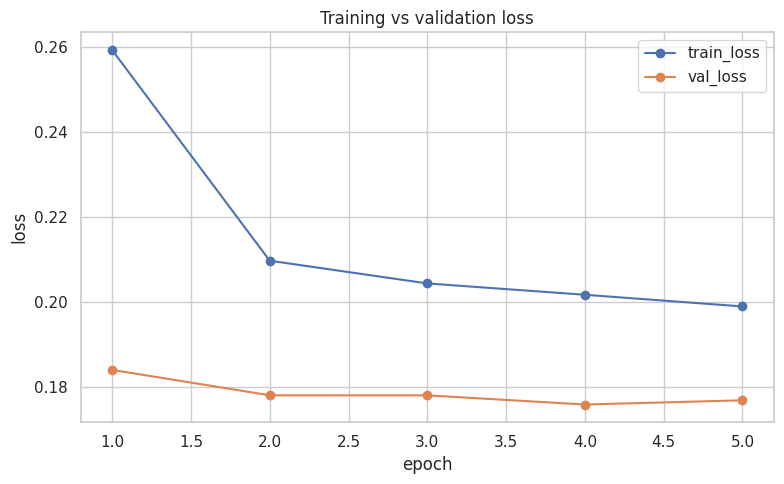

Saved: /kaggle/working/phobert_cluster_rank_mmr_outputs/06_key_train_val_loss.png


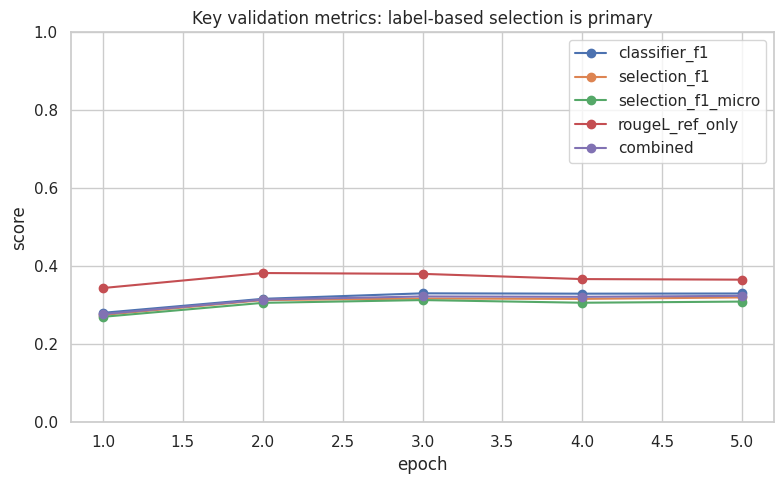

Saved: /kaggle/working/phobert_cluster_rank_mmr_outputs/07_key_val_classifier_selection_metrics.png


Running:   0%|          | 0/545 [00:00<?, ?it/s]

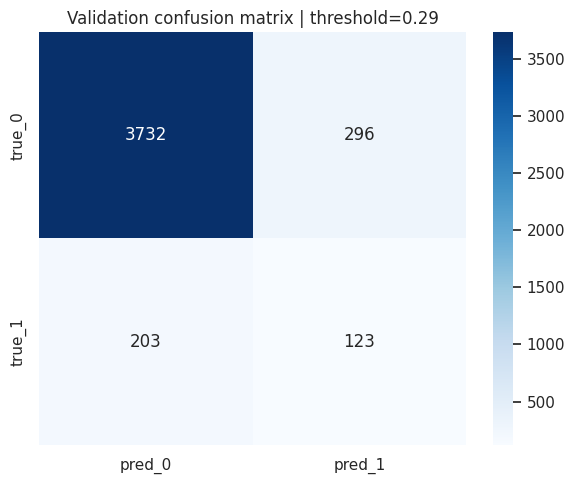

Saved: /kaggle/working/phobert_cluster_rank_mmr_outputs/08_key_validation_confusion_matrix.png


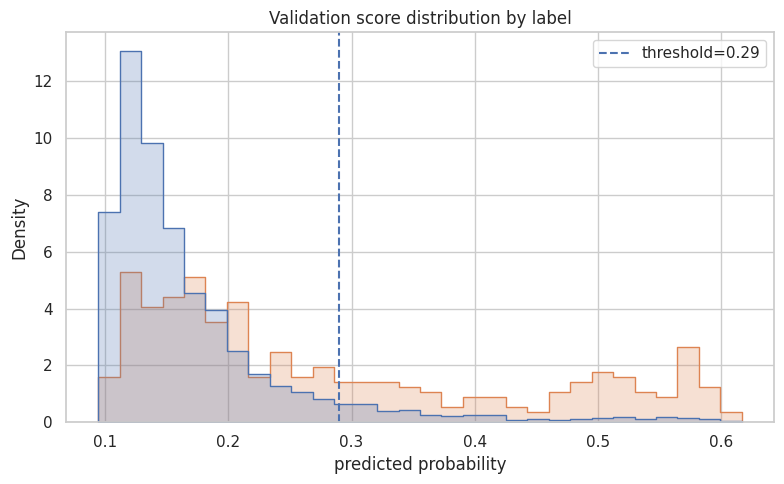

Saved: /kaggle/working/phobert_cluster_rank_mmr_outputs/09_key_validation_score_distribution.png


In [12]:
# ===== 9.1. KEY TRAINING / VALIDATION VISUALIZATION =====
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

sns.set_theme(style="whitegrid")

plot_dir = Path("/kaggle/working") / cfg.SAVE_DIRNAME if Path("/kaggle/working").exists() else Path.cwd() / cfg.SAVE_DIRNAME
plot_dir.mkdir(parents=True, exist_ok=True)


def _savefig(name: str):
    path = plot_dir / name
    plt.tight_layout()
    plt.savefig(path, dpi=160, bbox_inches="tight")
    plt.show()
    print(f"Saved: {path}")


def plot_training_history(history_df: pd.DataFrame):
    if history_df is None or len(history_df) == 0:
        print("No history_df available. Train first or load training_history.csv.")
        return

    hist = history_df.copy()

    # 1. Loss: xem overfitting/underfitting.
    plt.figure(figsize=(8, 5))
    plt.plot(hist["epoch"], hist["train_loss"], marker="o", label="train_loss")
    plt.plot(hist["epoch"], hist["val_loss"], marker="o", label="val_loss")
    plt.title("Training vs validation loss")
    plt.xlabel("epoch")
    plt.ylabel("loss")
    plt.legend()
    _savefig("06_key_train_val_loss.png")

    # 2. Metric sát mục tiêu: classifier F1 + selection F1. ROUGE-L chỉ tham khảo.
    plt.figure(figsize=(8, 5))
    if "val_f1" in hist.columns:
        plt.plot(hist["epoch"], hist["val_f1"], marker="o", label="classifier_f1")
    if "selection_f1" in hist.columns:
        plt.plot(hist["epoch"], hist["selection_f1"], marker="o", label="selection_f1")
    if "selection_f1_micro" in hist.columns:
        plt.plot(hist["epoch"], hist["selection_f1_micro"], marker="o", label="selection_f1_micro")
    if "rougeL" in hist.columns:
        plt.plot(hist["epoch"], hist["rougeL"], marker="o", label="rougeL_ref_only")
    if "combined" in hist.columns:
        plt.plot(hist["epoch"], hist["combined"], marker="o", label="combined")
    plt.title("Key validation metrics: label-based selection is primary")
    plt.xlabel("epoch")
    plt.ylabel("score")
    plt.ylim(0, 1)
    plt.legend()
    _savefig("07_key_val_classifier_selection_metrics.png")


def plot_validation_diagnostics(model, tokenizer, val_df, threshold=0.5):
    val_ds = SentenceImportanceDataset(val_df, tokenizer, cfg.MAX_LEN, has_labels=True, numeric_feature_columns=get_numeric_feature_columns(cfg))
    val_loader = DataLoader(val_ds, batch_size=cfg.BATCH_SIZE, shuffle=False, num_workers=0)
    _, y_true, probs = run_epoch(model, val_loader, criterion=None, cfg=cfg)
    y_pred = (probs >= threshold).astype(int)

    # 3. Confusion matrix: xem model đang thiên precision hay recall.
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["pred_0", "pred_1"], yticklabels=["true_0", "true_1"])
    plt.title(f"Validation confusion matrix | threshold={threshold:.2f}")
    _savefig("08_key_validation_confusion_matrix.png")

    # 4. Score distribution: xem xác suất của lớp 0/1 có tách nhau không.
    diag = pd.DataFrame({"label": y_true, "prob": probs})
    plt.figure(figsize=(8, 5))
    sns.histplot(data=diag, x="prob", hue="label", bins=30, element="step", stat="density", common_norm=False)
    plt.axvline(threshold, linestyle="--", label=f"threshold={threshold:.2f}")
    plt.title("Validation score distribution by label")
    plt.xlabel("predicted probability")
    plt.legend()
    _savefig("09_key_validation_score_distribution.png")


# Sau khi train xong:
plot_training_history(history_df)
plot_validation_diagnostics(model, tokenizer, val_df, threshold=best_threshold)


In [13]:
# ===== 10. Evaluate best checkpoint on validation/test =====

# Load best checkpoint before final evaluation.
ckpt = torch.load(best_ckpt_path, map_location=device, weights_only=False)
model.load_state_dict(ckpt["model_state_dict"])
model.to(device)
model.eval()

# Áp đúng decoder params đã thắng trên validation ở epoch tốt nhất.
best_decoder_params = ckpt.get("best_decoder_params", {})
if best_decoder_params:
    apply_decoder_params_to_cfg(cfg, best_decoder_params, verbose=True)
print("Best epoch:", ckpt.get("best_epoch"), "best_metric:", ckpt.get("best_metric"), "best_score:", ckpt.get("best_score"))

val_summary_metrics = evaluate_summarization_by_cluster(val_df, model, tokenizer, cfg)
print("\n=== Validation metrics ===")
print({k: v for k, v in val_summary_metrics.items() if k != "detail"})
val_summary_metrics["detail"].to_csv(Path(best_ckpt_path).parent / "val_summary_detail.csv", index=False)

if len(test_df) > 0:
    test_summary_metrics = evaluate_summarization_by_cluster(test_df, model, tokenizer, cfg)
    print("\n=== Test metrics ===")
    print({k: v for k, v in test_summary_metrics.items() if k != "detail"})
    test_summary_metrics["detail"].to_csv(Path(best_ckpt_path).parent / "test_summary_detail.csv", index=False)


Applied decoder params: {'MIN_SENT_SCORE': 0.35, 'SUMMARY_MAX_SENTENCES': 7, 'MIN_REQUIRED_SENTENCES': 2, 'SUMMARY_MAX_WORDS': 240, 'MMR_ALPHA': 0.65, 'REDUNDANCY_WEIGHT': 0.25, 'CENTRALITY_WEIGHT': 0.0}
Best epoch: 5 best_metric: selection_f1 best_score: 0.32013138258752294


Summary eval by cluster:   0%|          | 0/45 [00:00<?, ?it/s]


=== Validation metrics ===
{'selection_precision': 0.45084656084656083, 'selection_recall': 0.2637786904453571, 'selection_f1': 0.32013138258752294, 'selection_precision_micro': 0.418848167539267, 'selection_recall_micro': 0.24539877300613497, 'selection_f1_micro': 0.3094777562862669, 'avg_selected_sents': 4.2444444444444445, 'avg_gold_pos': 7.2444444444444445, 'avg_selected_pos': 1.7777777777777777, 'rouge1': 0.6138463047724044, 'rouge2': 0.39385954517104244, 'rougeL': 0.36568374475501814, 'avg_pred_sents': 4.2444444444444445, 'avg_redundancy': 0.16852828477679077}


Summary eval by cluster:   0%|          | 0/30 [00:00<?, ?it/s]


=== Test metrics ===
{'selection_precision': 0.38785714285714284, 'selection_recall': 0.2505154105154105, 'selection_f1': 0.2965974929210223, 'selection_precision_micro': 0.3691275167785235, 'selection_recall_micro': 0.24336283185840707, 'selection_f1_micro': 0.2933333333333333, 'avg_selected_sents': 4.966666666666667, 'avg_gold_pos': 7.533333333333333, 'avg_selected_pos': 1.8333333333333333, 'rouge1': 0.6354544246913923, 'rouge2': 0.3914065616140214, 'rougeL': 0.3766277478109548, 'avg_pred_sents': 4.966666666666667, 'avg_redundancy': 0.2036751566005366}


In [14]:
# ===== 11. Inspect one predicted summary =====

def show_cluster_summary(cluster_id, df_source=val_df):
    cluster_df = df_source[df_source["cluster_id"].astype(str) == str(cluster_id)].reset_index(drop=True)
    if cluster_df.empty:
        print("Cluster not found:", cluster_id)
        return None
    pred = summarize_cluster(cluster_df, model, tokenizer, cfg)
    gold = get_gold_summary_for_cluster(cluster_df)
    label_metrics = selected_label_metrics(cluster_df, pred["selected_indices"])
    print("CLUSTER:", cluster_id)
    print("\n--- LABEL-BASED SELECTION METRICS ---")
    print(label_metrics)
    print("\n--- SELECTED SENTENCES ---")
    display(pred["selected_info"])
    print("\n--- PRED SUMMARY ---")
    print(pred["summary"])
    print("\n--- GOLD SUMMARY / reference only ---")
    print(gold)
    print("\n--- ROUGE / reference only ---")
    print(rouge_scores(pred["summary"], gold))
    return pred

# Example:
sample_cluster = val_df["cluster_id"].iloc[0]
show_cluster_summary(sample_cluster)


CLUSTER: 2

--- LABEL-BASED SELECTION METRICS ---
{'selection_precision': 0.5, 'selection_recall': 0.2, 'selection_f1': 0.28571428571428575, 'n_gold_pos': 5, 'n_selected': 2, 'n_selected_pos': 1}

--- SELECTED SENTENCES ---


,cluster_id,doc_id,sent_clus_pos,sent_doc_pos,label,sentence,model_score,position_score,centrality_score,final_score,decoding_mode
0,2,3,19,0,1,trong bài phỏng_vấn với đài_cnn của mỹ hôm 19 ...,0.326024,0.767082,0.866667,0.242599,cluster_mmr
1,2,5,50,8,0,"trước đó , chiếc máy_bay airbus a320 số_hiệu m...",0.408035,0.119786,0.500000,0.270014,cluster_mmr



--- PRED SUMMARY ---
trong bài phỏng_vấn với đài_cnn của mỹ hôm 19 5 , bà hillary clinton nói tôi sẽ trở_thành ứng_viên đại_diện cho đảng của tôi đảng dân_chủ . trước đó , chiếc máy_bay airbus a320 số_hiệu ms804 đã rơi xuống địa_trung_hải khi đang trên đường từ paris tới cairo .

--- GOLD SUMMARY / reference only ---
trong cuộc phỏng_vấn trên cnn hôm 19 5 , bà hillary_clinton cho biết , bà chắc_chắn sẽ là người đại_diện cho đảng dân_chủ ra tranh_cử tổng_thống mỹ . ứng_viên tổng_thống mỹ_hillary clinton_đảng dân_chủ ngày 19.5 chỉ_trích đối_thủ_đảng cộng_hòa , tỉ_phú donald trump là mối đe_dọa đối_với nền dân_chủ_mỹ , và tuyên_bố ông trump không đủ tư_cách làm tổng_thống . ứng_viên tổng_thống đảng dân_chủ hillary clinton nói rằng cuộc đua giữa bà và thượng_nghị_sĩ bernie_sanders đã thực_sự ngã_ngũ , và bà sẽ là ứng_viên đại_diện cho đảng dân_chủ trong cuộc đua vào nhà trắng năm nay . bà hillary clinton hôm_qua nói donald_trump là mối đe_dọa đối_với nền dân_chủ_mỹ và tuyên_bố ông không đ

{'summary': 'trong bài phỏng_vấn với đài_cnn của mỹ hôm 19 5 , bà hillary clinton nói tôi sẽ trở_thành ứng_viên đại_diện cho đảng của tôi đảng dân_chủ . trước đó , chiếc máy_bay airbus a320 số_hiệu ms804 đã rơi xuống địa_trung_hải khi đang trên đường từ paris tới cairo .',
 'selected_indices': [19, 50],
 'scores': array([0.13590926, 0.11929332, 0.18567665, 0.18576166, 0.22981337,
        0.11114537, 0.14700042, 0.1865067 , 0.14100236, 0.19407392,
        0.11508273, 0.13219595, 0.17297591, 0.14743672, 0.14986596,
        0.17264794, 0.26754701, 0.18674108, 0.18576656, 0.32602358,
        0.11056155, 0.11526097, 0.1863938 , 0.14142635, 0.15289767,
        0.16505402, 0.13676414, 0.13547407, 0.27758694, 0.12295812,
        0.12601423, 0.15038916, 0.23979126, 0.11602822, 0.10722777,
        0.11741813, 0.16727978, 0.14290747, 0.10426001, 0.14680269,
        0.1016034 , 0.10898623, 0.14194046, 0.11816207, 0.11637624,
        0.17276861, 0.2506223 , 0.11384393, 0.10078531, 0.11967726,
     